# Tapering granularity: Scenario 2 with dipole trims

This follows Scenario 1, but the final horizontal-orbit correction uses one trim per cell of the arc+DS regions. `TRIM_POSITION_IN_CELL` chooses which bend of a three-dipole cell carries it; the two-dipole cells next to the straight sections, at the beginning and at the end of the dispersion suppressors, follow along through `TRIM_INDEX_IN_CELL` — their first bend for positions 1 and 2, their second bend for position 3.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import re

from tapering import *

In [2]:
line_path = "/Users/skostogl/Documents/workspace/workspace_2026/FCC/07_2026/ground_motion_studies/acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json"
from pathlib import Path

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 120,
})

## Ideal Xsuite tapering

In [3]:
line = xt.load(line_path).fccee_p_ring
line.build_tracker(_context=xo.ContextCpu())
line.configure_radiation(model='mean')

Loading line from dict: 100%|██████████| 18995/18995 [00:02<00:00, 7601.94it/s]


In [4]:
line.compensate_radiation_energy_loss(delta0='zero_mean')

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.299 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.544 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


In [5]:
elements_with_taper = np.asarray([ name for name in line.element_names if hasattr(line[name], "delta_taper")], dtype=str)
ideal_delta_taper = np.asarray([float(line[name].delta_taper) for name in elements_with_taper], dtype=float).copy()
ideal_taper_by_name = dict(zip(elements_with_taper, ideal_delta_taper))
twiss_ideal = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
tt  = line.get_table()
print(f'Taperable elements: {len(ideal_delta_taper)}')
print(f'Ideal emittance: x={float(twiss_ideal.eq_gemitt_x)*1e9:.4g} nm, y={float(twiss_ideal.eq_gemitt_y)*1e12:.4g} pm')

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Taperable elements: 15985
Ideal emittance: x=2.189 nm, y=0.06379 pm


In [6]:
def clear_delta_taper(line, elements_with_taper ):
    for name in elements_with_taper:
        line[name].delta_taper = 0.0

def restore_ideal_tapering(line,elements_with_taper, ideal_delta_taper):
    for name, value in zip(elements_with_taper, ideal_delta_taper):
        line[name].delta_taper = float(value)


def read_rf_phase(line):
    rows = []

    for name in line.element_names:
        element = line[name]

        if not hasattr(element, "voltage"):
            continue

        voltage = float(element.voltage)

        if voltage == 0:
            continue

        phase_taper = float(
            getattr(element, "phase_taper", 0.0)
        )

        rows.append({
            "name": name,
            "voltage_MV": voltage * 1e-6,
            "phase_taper_rad": phase_taper,
            "phase_taper_deg": np.rad2deg(phase_taper),
        })

    return pd.DataFrame(rows)

In [7]:
rf_phase_ideal = read_rf_phase(line)
rf_phase_ideal 

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [8]:
clear_delta_taper(line, elements_with_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_no_tapering = read_rf_phase(line)

/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 2): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/Users/skostogl/Documents/workspace/workspace_2026/FCC/

In [9]:
rf_phase_ideal

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [10]:
rf_phase_no_tapering

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.122084,-64.290690
1,rf800.0,4020.0,-1.140986,-65.373703
2,rf800.1,4020.0,-1.140986,-65.373703
3,rf400.1,990.0,-1.122084,-64.290690


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


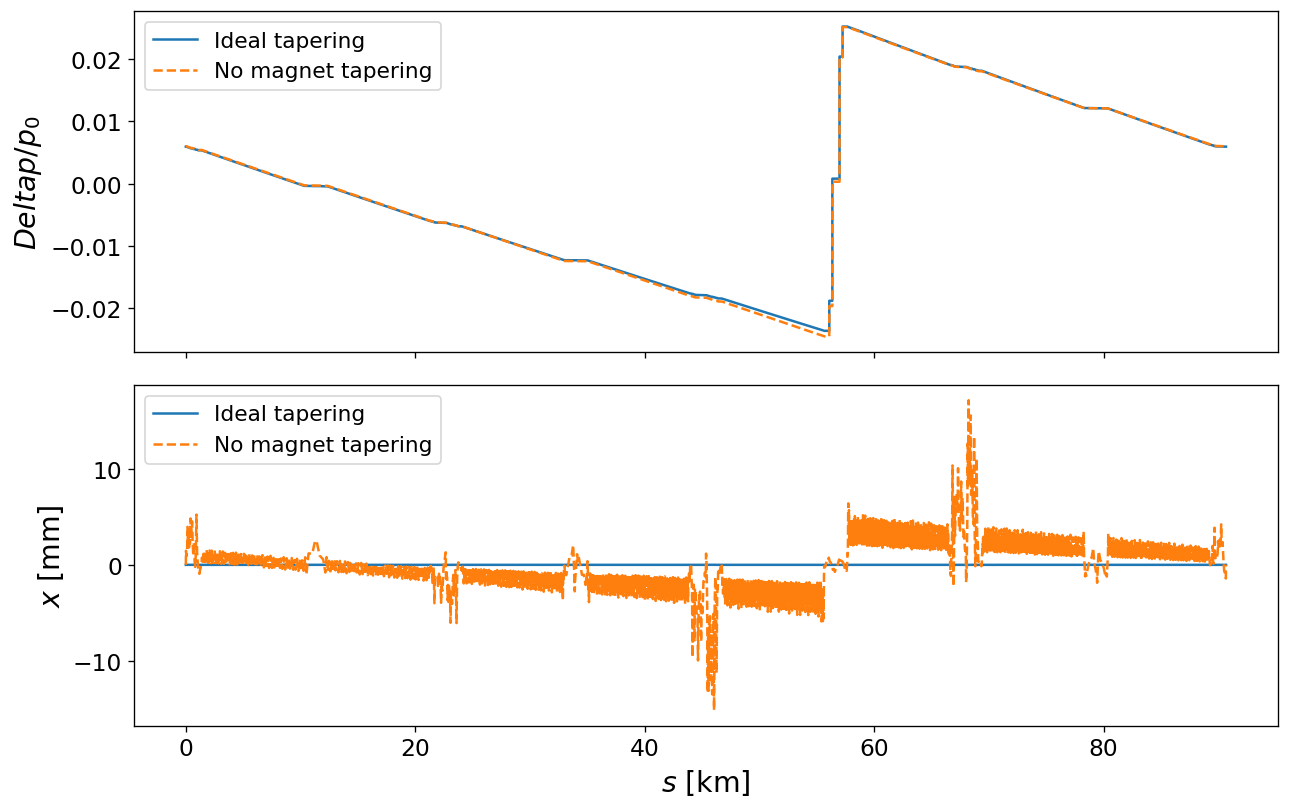

In [11]:
tw_no_taper = line.twiss(eneloss_and_damping=True)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[0].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[0].set_ylabel(
    r"$Delta p/p_0$"
)

axes[0].legend()


axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[1].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[1].set_xlabel(
    r"$s$ [km]"
)

axes[1].set_ylabel(
    r"$x$ [mm]"
)

axes[1].legend()

fig.tight_layout()
plt.show()




In [12]:
# use markers to split into regions
def split_lattice_regions(line):
    ips = ["ipa", "ipb", "ipd", "ipf", "ipg", "iph", "ipj", "ipl"]

    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)

    valid = names != "_end_point"
    names = names[valid]
    s = s[valid]

    s_by_name = dict(zip(names, s))

    def select(start_marker, end_marker):
        start = s_by_name[start_marker]
        end = s_by_name[end_marker]

        if start <= end:
            mask = (s >= start) & (s < end)
        else:
            mask = (s >= start) | (s < end)

        return names[mask]

    arcs = {}
    arc_ds = {}
    ds = {}
    insertions = {}

    for i, left_ip in enumerate(ips):
        right_ip = ips[(i + 1) % len(ips)]
        sector = f"{left_ip}_{right_ip}"

        arcs[sector] = select(
            f"end_ds_start_arc_{left_ip}",
            f"end_arc_start_ds_{right_ip}",
        )

        arc_ds[sector] = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        right_ds = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_arc_{left_ip}",
        )

        left_ds = select(
            f"end_arc_start_ds_{right_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        ds[sector] = np.concatenate([right_ds, left_ds])

        insertions[right_ip] = select(
            f"end_ds_start_straight_{right_ip}",
            f"end_straight_start_ds_{right_ip}",
        )

    return {
        "arcs": arcs,
        "arc_ds": arc_ds,
        "ds": ds,
        "insertions": insertions,
    }

regions = split_lattice_regions(line)
regions


{'arcs': {'ipa_ipb': array(['bpm_qd1am.0', 'end_ds_start_arc_ipa', 'qd1am.0', ...,
         '||drift_30::323', 'bpm_qd1am.50', 'qd1am.50'],
        shape=(3053,), dtype='<U25'),
  'ipb_ipd': array(['end_ds_start_arc_ipb', 'qd1am.52', 'bpm_qd1am.52', ...,
         'mbd.1634', '||drift_36::287', 'qd1am.102'],
        shape=(3052,), dtype='<U25'),
  'ipd_ipf': array(['bpm_qd1am.104', 'end_ds_start_arc_ipd', 'qd1am.104', ...,
         '||drift_36::938', 'bpm_qd1am.154', 'qd1am.154'],
        shape=(3053,), dtype='<U25'),
  'ipf_ipg': array(['end_ds_start_arc_ipf', 'qd1am.156', 'bpm_qd1am.156', ...,
         'mbd.3314', '||drift_36::1473', 'qd1am.206'],
        shape=(3052,), dtype='<U25'),
  'ipg_iph': array(['bpm_qd1am.208', 'end_ds_start_arc_ipg', 'qd1am.208', ...,
         '||drift_36::2118', 'bpm_qd1am.258', 'qd1am.258'],
        shape=(3053,), dtype='<U25'),
  'iph_ipj': array(['end_ds_start_arc_iph', 'qd1am.260', 'bpm_qd1am.260', ...,
         'mbd.4934', '||drift_89::9', 'qd1am.310'

# Step 1: set insertions to perfect tapering

In [13]:
clear_delta_taper(line, elements_with_taper)

# make it flat for all inserions
insertion_element_names_flat = np.concatenate(list(regions["insertions"].values()))

# filter only the elements that have tapering
insertion_mask = np.isin(elements_with_taper,insertion_element_names_flat)

insertion_elements_with_taper = elements_with_taper[insertion_mask]
insertion_ideal_delta_taper = ideal_delta_taper[insertion_mask]

restore_ideal_tapering(line, insertion_elements_with_taper, insertion_ideal_delta_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_insertions = read_rf_phase(line)

print(f"Restored ideal tapering for " f"{len(insertion_elements_with_taper)} insertion elements.")
rf_phase_insertions

/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Restored ideal tapering for 1587 insertion elements.


/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.119203,-64.125604
1,rf800.0,4020.0,-1.135224,-65.043531
2,rf800.1,4020.0,-1.135224,-65.043531
3,rf400.1,990.0,-1.119203,-64.125604


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


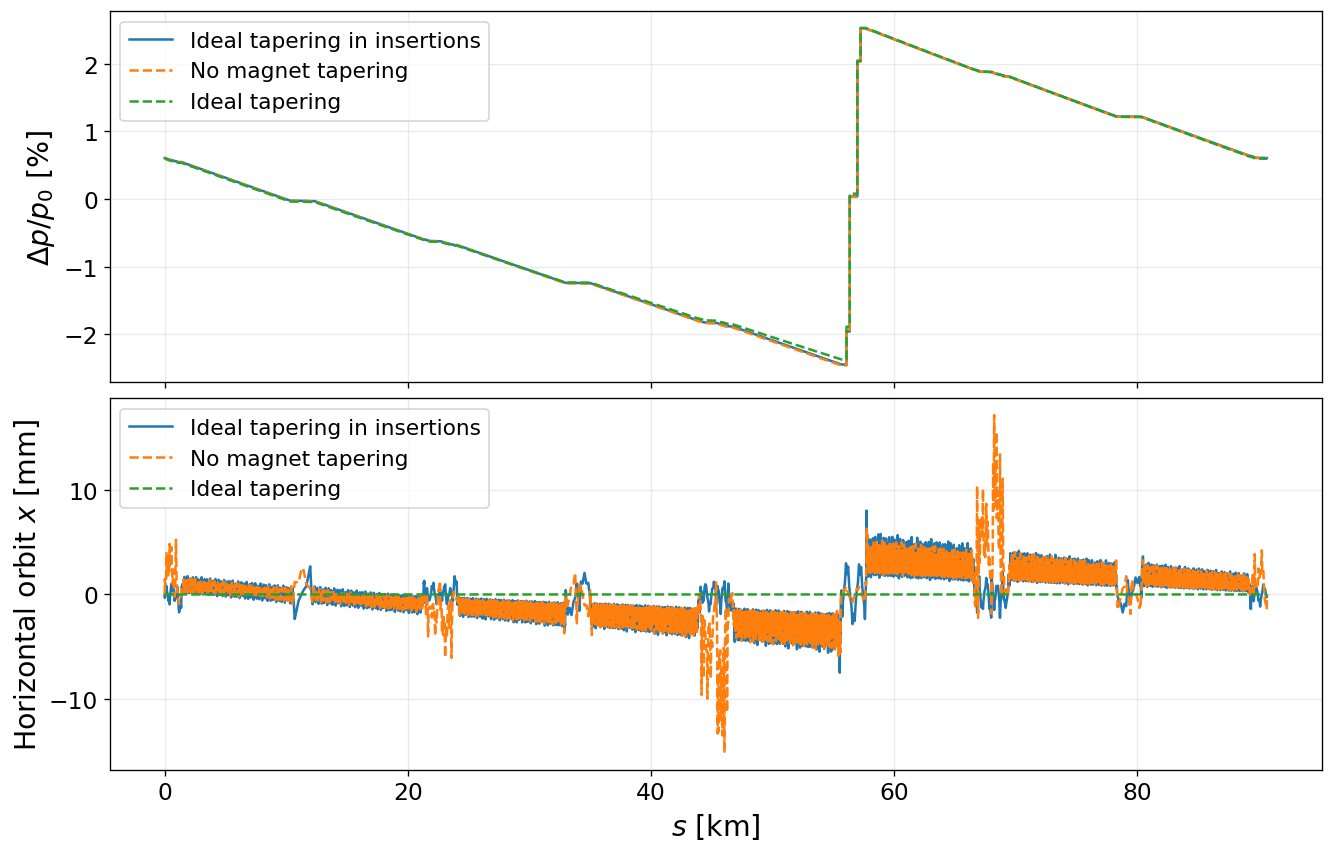

Saved: figures/scenario2_insertion_tapering_orbit_comparison.png


In [14]:


# twiss and plot orbit
twiss_insertion_taper = line.twiss(eneloss_and_damping=True)

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 7),
    sharex=True,
    layout="constrained",
)

cases = [
    (
        twiss_insertion_taper,
        "Ideal tapering in insertions",
        "tab:blue",
        "-",
    ),
    (
        tw_no_taper,
        "No magnet tapering",
        "tab:orange",
        "--",
    ),
    (
        twiss_ideal,
        "Ideal tapering",
        "tab:green",
        "--",
    ),
]

# Relative momentum deviation
for twiss, label, color, linestyle in cases:
    axes[0].plot(
        np.asarray(twiss.s) / 1e3,
        np.asarray(twiss.delta)*1e2,
        color=color,
        ls=linestyle,
        lw=1.5,
        label=label,
    )

axes[0].set_ylabel(r"$\Delta p/p_0$ [%]")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.25)

# Horizontal closed orbit
for twiss, label, color, linestyle in cases:
    axes[1].plot(
        np.asarray(twiss.s) / 1e3,
        np.asarray(twiss.x) * 1e3,
        color=color,
        ls=linestyle,
        lw=1.5,
        label=label,
    )

axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"Horizontal orbit $x$ [mm]")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.25)

figure_path = FIGURE_DIR / "scenario2_insertion_tapering_orbit_comparison.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

# Define circuits

In [15]:
# Define the number of tapering circuits for dipoles per sector. It should not separate dipoles of a cell in different circuits.
# n  :   1    2    4    5    7    8   10   14   20   28   35   40   56   70  140  280
# size: 840  420  210  168  120  105   84   60   42   30   24   21   15   12    6    3

N_DIPOLE_CIRCUITS_PER_SECTOR = 1

In [16]:
import re
import numpy as np
import pandas as pd


def define_arc_circuits(line, regions, n_dipole_circuits_per_sector=1):
    table = line.get_table()

    type_by_name = dict(
        zip(
            np.asarray(table.name, dtype=str),
            np.asarray(table.element_type, dtype=str),
        )
    )

    taperable = {
        name
        for name in line.element_names
        if hasattr(line[name], "delta_taper")
    }

    def family(name):
        # qf2a.15 -> qf2a
        # sf1a.32 -> sf1a
        return re.sub(r"\.\d+$", "", name.lower())

    def select(elements, element_type=None, prefix=None):
        selected = []

        for name in elements:
            if name not in taperable:
                continue

            if element_type is not None:
                if element_type not in type_by_name.get(name, ""):
                    continue

            if prefix is not None:
                prefixes = (
                    (prefix,)
                    if isinstance(prefix, str)
                    else tuple(prefix)
                )

                if not family(name).startswith(prefixes):
                    continue

            selected.append(name)

        return np.asarray(selected, dtype=str)

    def split_in_two(elements):
        """
        Split an ordered family into two contiguous circuits.

        The first circuit contains the first half of the magnets along s.
        The second circuit contains the remaining magnets.
        """
        elements = np.asarray(elements, dtype=str)

        first, second = np.array_split(elements, 2)

        return first, second
    
    def split_in_n(elements, n):
            """
            Split an ordered family into n contiguous circuits.
    
            The first circuit contains the first m/n magnets along s.
            The second circuit contains the next m/n magnets.
            etc. The last circuit contains the remaining magnets.
            """
            elements = np.asarray(elements, dtype=str)
    
            split_elements = np.array_split(elements, n)
    
            return split_elements

    circuits = {}

    for sector in regions["arcs"]:

        arc_elements = regions["arcs"][sector]
        arc_ds_elements = regions["arc_ds"][sector]
        
        # --------------------------------------------------------------
        # Dipoles
        # 
        # Can't use the original circuits because of the twin aperture.
        # New circuits with different granularity are defined here.
        # 
        # Circuit names: DIP_1, DIP_2, ..., DIP_n
        # --------------------------------------------------------------

        dipole_elements = select(
            arc_ds_elements,
            element_type="Bend",
        )
        
        dipoles_circuits = split_in_n(dipole_elements, n_dipole_circuits_per_sector)
        for i, dipole_circuit in enumerate(dipoles_circuits):
            circuits[f"DIP_{i+1}_{sector}"] = dipole_circuit

        # --------------------------------------------------------------
        # Quadrupoles
        #
        # Original circuits:
        #   QF, QD
        #
        # New circuits:
        #   QF_1, QF_2, QD_1, QD_2
        # --------------------------------------------------------------

        qf_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix=("qf2a", "qf3a"),
        )

        qd_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qd1a", # qd1a and qd1am
        )

        qf_1, qf_2 = split_in_two(qf_elements)
        qd_1, qd_2 = split_in_two(qd_elements)

        circuits[f"QF_1_{sector}"] = qf_1
        circuits[f"QF_2_{sector}"] = qf_2
        circuits[f"QD_1_{sector}"] = qd_1
        circuits[f"QD_2_{sector}"] = qd_2

        # --------------------------------------------------------------
        # Sextupoles
        #
        # Original circuits:
        #   SF1, SF2, SD1, SD2
        #
        # Each family is one circuit per arc.
        # --------------------------------------------------------------

        sextupole_families = {
            "SF1": "sf1a",
            "SF2": "sf2a",
            "SD1": "sd1a",
            "SD2": "sd2a",
        }

        for circuit_family, prefix in sextupole_families.items():

            family_elements = select(
                arc_elements,
                element_type="Sextupole",
                prefix=prefix,
            )
            
            circuits[f"{circuit_family}_{sector}"] = family_elements

    # Remove empty circuits.
    circuits = {
        name: elements
        for name, elements in circuits.items()
        if len(elements) > 0
    }

    return circuits

In [17]:
! pwd

/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering


In [18]:

circuits = define_arc_circuits(line, regions, n_dipole_circuits_per_sector=N_DIPOLE_CIRCUITS_PER_SECTOR)

summary = pd.DataFrame([
    {
        "circuit": circuit,
        "number_of_elements": len(elements),
        "first_element": elements[0],
        "last_element": elements[-1],
    }
    for circuit, elements in circuits.items()
])

display(summary)

,circuit,number_of_elements,first_element,last_element
0,DIP_1_ipa_ipb,840,mbd.0,mbd.839
1,QF_1_ipa_ipb,67,qf2a.0,qf3a.13
2,QF_2_ipa_ipb,66,qf2a.53,qf2a.105
3,QD_1_ipa_ipb,67,qd1a.0,qd1a.53
4,QD_2_ipa_ipb,67,qd1a.54,qd1a.107
...,...,...,...,...
67,QD_2_ipl_ipa,67,qd1a.810,qd1a.863
68,SF1_ipl_ipa,50,sf1a.358,sf1a.407
69,SF2_ipl_ipa,50,sf2a.358,sf2a.407
70,SD1_ipl_ipa,50,sd1a.358,sd1a.407


In [19]:
circuits['DIP_1_iph_ipj']

array(['mbd3r_rf.0', 'mbd3r_rf.1', 'mbd3r_rf.2', 'mbd2r_rf.0',
       'mbd2r_rf.1', 'mbd2r_rf.2', 'mbd1r_rf.0', 'mbd1r_rf.1',
       'mbd1r_rf.2', 'mbd.4179', 'mbd.4180', 'mbd.4181', 'mbd9r_rf.0',
       'mbd9r_rf.1', 'mbd9r_rf.2', 'mbd9r_rf.3', 'mbd9r_rf.4',
       'mbd9r_rf.5', 'mbd9r_rf.6', 'mbd9r_rf.7', 'mbd9r_rf.8',
       'mbd8r_rf.0', 'mbd8r_rf.1', 'mbd8r_rf.2', 'mbd8r_rf.3',
       'mbd8r_rf.4', 'mbd8r_rf.5', 'mbd8r_rf.6', 'mbd8r_rf.7',
       'mbd8r_rf.8', 'mbd.4182', 'mbd.4183', 'mbd.4184', 'mbd0r_rf.0',
       'mbd0r_rf.1', 'mbd0r_rf.2', 'mbd0r_rf.3', 'mbd0r_rf.4',
       'mbd0r_rf.5', 'mbd0r_rf.6', 'mbd0r_rf.7', 'mbd0r_rf.8',
       'mbd0r_rf.9', 'mbd0r_rf.10', 'mbd0r_rf.11', 'mbd.4185', 'mbd.4186',
       'mbd.4187', 'mbd.4188', 'mbd.4189', 'mbd.4190', 'mbd.4191',
       'mbd.4192', 'mbd.4193', 'mbd.4194', 'mbd.4195', 'mbd.4196',
       'mbd.4197', 'mbd.4198', 'mbd.4199', 'mbd.4200', 'mbd.4201',
       'mbd.4202', 'mbd.4203', 'mbd.4204', 'mbd.4205', 'mbd.4206',
       'mbd

# Step 2: set dipoles in coarse granularity

In [20]:
def circuit_average_tapering_setters(line, circuits, dipole_tapering=True, quadrupole_tapering=True, sextupole_tapering=True):
    """
    Return a list of MultiSetter objects for the given circuits for average tapering.

    Each MultiSetter object can be used to set the delta_taper field
    for all magnets in a circuit simultaneously.
    """
    delta_taper_setters = []

    for circuit in circuits.keys():
        
        if circuit.startswith("DIP") and dipole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("Q") and quadrupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("S") and sextupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )

    return delta_taper_setters

In [21]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=False, 
                                                            sextupole_tapering=False)

delta_taper_setters_zero = circuit_average_tapering_setters(line,
                                                            circuits,
                                                            dipole_tapering=False,
                                                            quadrupole_tapering=True,
                                                            sextupole_tapering=True)

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(8, 66)

In [22]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.08907115e-09], x=[-0.00182832], y=[-3.97353694e-12], px=[1.14683706e-05], py=[-1.66056912e-13], ptau=[0.00038806], delta=[0.00038806], rpp=[0.99961209], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -9070.80470971907
Energy loss diff.: 0.04970303950550481
Iteration 1


/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (tapering iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-0.00190771], x=[-6.36524966e-05], y=[1.75029332e-11], px=[1.10921689e-06], py=[7.49229601e-15], ptau=[0.00074192], delta=[0.00074192], rpp=[0.99925863], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8944.287609460693
Energy loss diff.: 0.0006932443849801267
Iteration 2
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.50312243e-06], x=[-7.47075184e-05], y=[1.50162357e-11], px=[1.20349384e-06], py=[2.29895895e-13], ptau=[0.00073782], delta=[0.00073782], rpp=[0.99926273], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=

In [23]:
def read_applied_tapering(line, circuits, circuit_prefixes, ideal_taper_by_name):
    applied_settings = []

    for circuit_name, circuit_elements in circuits.items():

        if not circuit_name.startswith(tuple(circuit_prefixes)):
            continue

        elements = [
            name for name in circuit_elements
            if name in ideal_taper_by_name
        ]

        if len(elements) == 0:
            continue

        applied_values = np.asarray(
            [float(line[name].delta_taper) for name in elements],
            dtype=float,
        )

        ideal_values = np.asarray(
            [ideal_taper_by_name[name] for name in elements],
            dtype=float,
        )

        applied_settings.append({
            "circuit": circuit_name,
            "number_of_elements": len(elements),
            "applied_delta_taper": np.mean(applied_values),
            "ideal_min": np.min(ideal_values),
            "ideal_max": np.max(ideal_values),
            "maximum_error": np.max(
                np.abs(ideal_values - applied_values)
            ),
        })

    return pd.DataFrame(applied_settings)

In [24]:
read_applied_tapering(line, circuits, ["DIP"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,DIP_1_ipa_ipb,840,0.002429,-0.000367,0.005360,0.002931
1,DIP_1_ipb_ipd,840,-0.003305,-0.006037,-0.000440,0.002865
2,DIP_1_ipd_ipf,840,-0.009673,-0.012334,-0.006879,0.002794
3,DIP_1_ipf_ipg,840,-0.015095,-0.017698,-0.012361,0.002734
4,DIP_1_ipg_iph,840,-0.021169,-0.023708,-0.018501,0.002668
5,DIP_1_iph_ipj,840,0.022133,0.019107,0.025289,0.003156
6,DIP_1_ipj_ipl,840,0.015098,0.012155,0.018177,0.003079
7,DIP_1_ipl_ipa,840,0.009117,0.006244,0.012125,0.003009


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


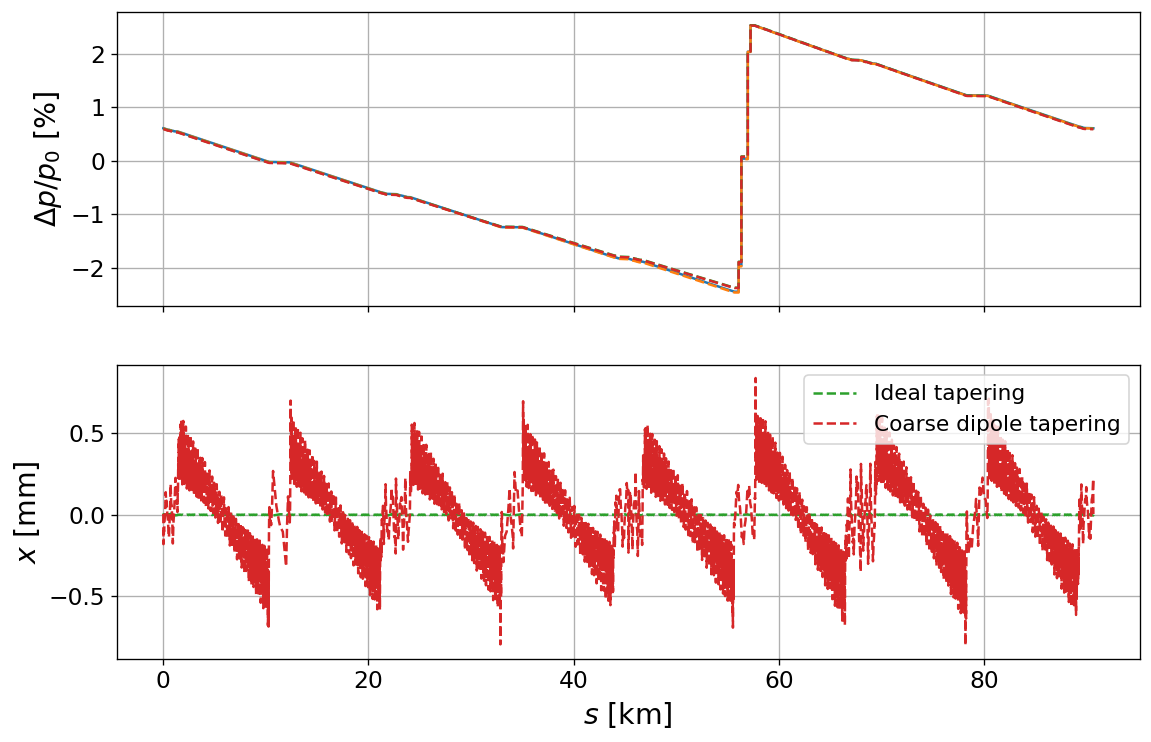

In [25]:
rf_phase_dipole = read_rf_phase(line)

# Twiss and plot orbit
twiss_dipole = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta*1e2,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta*1e2,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta*1e2,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.delta*1e2,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

axes[0].set_ylabel(r"$\Delta p/p_0$ [%]")
plt.grid(True)
plt.sca(axes[1])
#plt.plot(
#    twiss_insertion_taper.s / 1e3,
#    twiss_insertion_taper.x * 1e3,
#    color="tab:blue",
#    lw=1.5,
#    label="Tapering in insertions",
#)
#plt.plot(
#    tw_no_taper.s / 1e3,
#    tw_no_taper.x * 1e3,
#    color="tab:orange",
#    ls="--",
#    lw=1.5,
#    label="No magnet tapering",
#)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)
plt.grid(True)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")
figure_path = FIGURE_DIR / "granularity_scenario2_dipole_trims.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

# Step 3 set quad and sextupoles in coarse granularity

In [26]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=True, 
                                                            sextupole_tapering=True)

delta_taper_setters_zero =[]

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(72, 2)

In [27]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-4.35656225e-07], x=[-7.36218841e-05], y=[2.00011777e-13], px=[1.19594697e-06], py=[1.01769189e-15], ptau=[0.00073116], delta=[0.00073116], rpp=[0.99926938], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8943.945330882094
Energy loss diff.: 0.04900791962146385
Iteration 1
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[1.00746828e-06], x=[-0.00011609], y=[-5.40854574e-13], px=[1.56298489e-06], py=[-7.11799026e-15], ptau=[0.00073322], delta=[0.00073322], rpp=[0.9

In [28]:
# Quadrupoles tapering
read_applied_tapering(line, circuits, [ "QF", "QD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,QF_1_ipa_ipb,67,0.003799,0.002480,0.005198,0.001399
1,QF_2_ipa_ipb,66,0.001075,-0.000209,0.002439,0.001364
2,QD_1_ipa_ipb,67,0.003819,0.002500,0.005218,0.001399
3,QD_2_ipa_ipb,67,0.001075,-0.000229,0.002459,0.001384
4,QF_1_ipb_ipd,67,-0.001967,-0.003254,-0.000598,0.001368
5,QF_2_ipb_ipd,66,-0.004628,-0.005882,-0.003294,0.001334
6,QD_1_ipb_ipd,67,-0.001947,-0.003234,-0.000578,0.001368
7,QD_2_ipb_ipd,67,-0.004628,-0.005902,-0.003274,0.001354
8,QF_1_ipd_ipf,67,-0.008368,-0.009622,-0.007033,0.001335
9,QF_2_ipd_ipf,66,-0.010962,-0.012183,-0.009661,0.001302


In [29]:
# Sextupoles tapering
read_applied_tapering(line, circuits, [ "SF", "SD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,SF1_ipa_ipb,50,0.002447,-0.000006,0.004991,0.002544
1,SF2_ipa_ipb,50,0.002447,-0.000046,0.005032,0.002585
2,SD1_ipa_ipb,50,0.002447,-0.000026,0.005011,0.002564
3,SD2_ipa_ipb,50,0.002447,0.000014,0.004970,0.002523
4,SF1_ipb_ipd,50,-0.003288,-0.005684,-0.000801,0.002487
5,SF2_ipb_ipd,50,-0.003288,-0.005723,-0.000760,0.002528
6,SD1_ipb_ipd,50,-0.003288,-0.005704,-0.000780,0.002507
7,SD2_ipb_ipd,50,-0.003288,-0.005664,-0.000821,0.002467
8,SF1_ipd_ipf,50,-0.009656,-0.011990,-0.007230,0.002425
9,SF2_ipd_ipf,50,-0.009656,-0.012029,-0.007191,0.002465


In [30]:
rf_phase_quad_sext = read_rf_phase(line)

rf_phase_quad_sext

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103220,-63.209845
1,rf800.0,4020.0,-1.103258,-63.212013
2,rf800.1,4020.0,-1.103258,-63.212013
3,rf400.1,990.0,-1.103220,-63.209845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

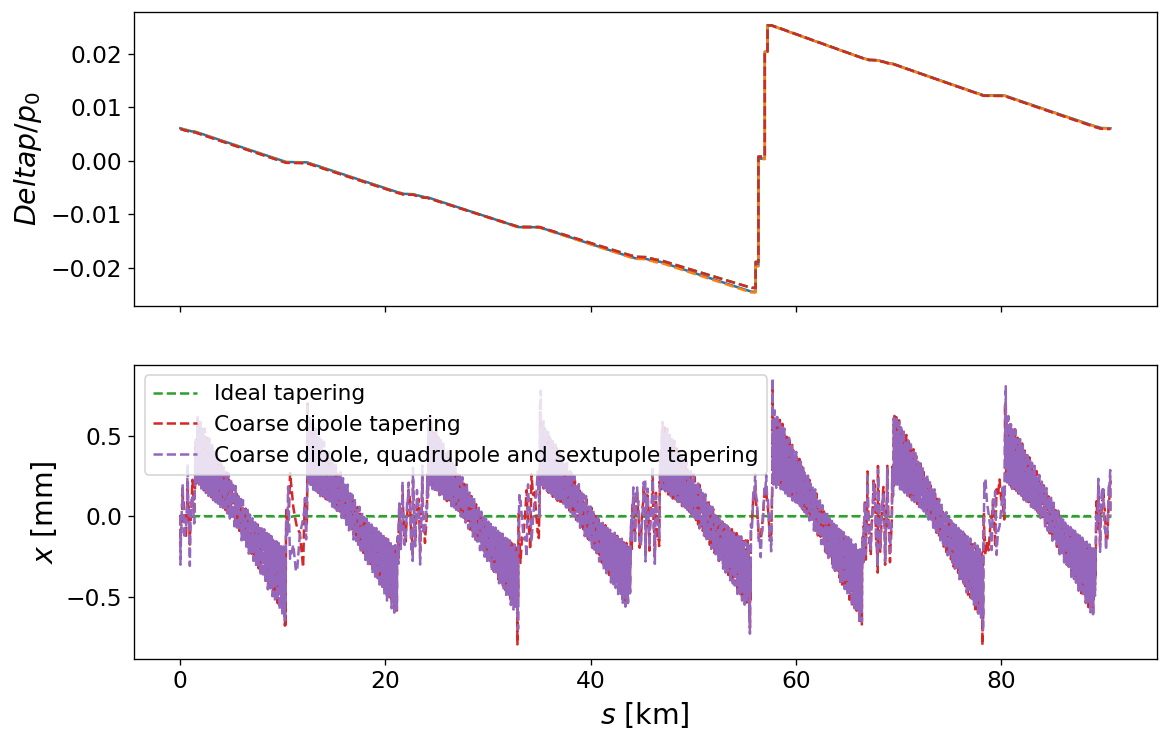

In [31]:
# twiss and plot orbit
twiss_quad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 4: correct the horizontal orbit with one dipole trim per arc+DS cell

In [32]:
twiss_ideal["length"]

array([0. , 0. , 2.4, ..., 2.4, 0. , 0. ], shape=(30053,))

In [33]:
from scipy.sparse.linalg import lsmr

# Which dipole of a three-dipole arc cell carries the trim: 1, 2 or 3.
TRIM_POSITION_IN_CELL = 1

# Index of the trim inside a cell, per choice of position and per cell size.
# The two-dipole cells of the dispersion suppressors follow the three-dipole
# cells as closely as they can: they stay on their first dipole for the first
# two positions and move to their second one for the third.
TRIM_INDEX_IN_CELL = {
    # position: {dipoles in the cell: index of the trim in the cell}
    1: {3: 0, 2: 0},
    2: {3: 1, 2: 0},
    3: {3: 2, 2: 1},
}


def dipole_cells_in_region(line, element_names):
    """Split a region into cells: the dipoles sitting between two quadrupoles.

    An arc cell holds three dipoles. Close to the straight sections, at the
    beginning and at the end of the dispersion suppressors, the cells hold two
    dipoles instead. The cells are therefore read from the lattice itself
    rather than by reshaping the dipole list in groups of three.
    """
    table = line.get_table()
    type_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.element_type, dtype=str),
    ))

    cells = []
    cell = []
    for name in np.asarray(element_names, dtype=str):
        element_type = type_by_name.get(str(name), "")
        if "Bend" in element_type:
            cell.append(str(name))
        elif "Quadrupole" in element_type and cell:
            cells.append(cell)
            cell = []
    if cell:
        cells.append(cell)

    sizes = sorted({len(cell) for cell in cells})
    if not set(sizes) <= {2, 3}:
        raise ValueError(
            f"cells of {sizes} dipoles found; only cells of two or three "
            "dipoles are expected in the arc+DS regions."
        )

    return cells


def select_trim_dipole_of_each_cell(line, regions, position=TRIM_POSITION_IN_CELL):
    """One dipole per arc+DS cell, used as a horizontal orbit corrector.

    `position` chooses which dipole of a three-dipole cell carries the trim:
    1 for the first, 2 for the second, 3 for the third. The two-dipole cells
    next to the straight sections follow along through `TRIM_INDEX_IN_CELL`:
    their first dipole for positions 1 and 2, their second one for position 3.
    There is still exactly one trim per cell everywhere.
    """
    if position not in TRIM_INDEX_IN_CELL:
        raise ValueError(
            f"position must be one of {sorted(TRIM_INDEX_IN_CELL)}, got {position}"
        )

    table = line.get_table()
    tw = line.twiss(eneloss_and_damping=True)
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    length_by_name = dict(zip(
        np.asarray(tw.name, dtype=str),
        np.asarray(tw.length, dtype=float),
    ))

    selected = []
    rows = []
    # i keep dipoles also in the DS
    for sector, arc_ds_elements in regions["arc_ds"].items():
        cells = dipole_cells_in_region(line, arc_ds_elements)

        for cell_number, cell in enumerate(cells):
            index = TRIM_INDEX_IN_CELL[position][len(cell)]
            trim_dipole = cell[index]
            selected.append(trim_dipole)

            row = {
                "sector": sector,
                "cell": cell_number,
                "dipoles_in_cell": len(cell),
                "position_in_cell": index + 1,
                "trim_dipole": trim_dipole,
                "s_km": s_by_name[trim_dipole] / 1e3,
                "length_m": length_by_name[trim_dipole],
            }
            # dipole_1, dipole_2 and, for the three-dipole cells, dipole_3.
            row.update({
                f"dipole_{i + 1}": name for i, name in enumerate(cell)
            })
            rows.append(row)

    return np.asarray(selected, dtype=str), pd.DataFrame(rows)


def validate_trim_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
    position=TRIM_POSITION_IN_CELL,
):
    expected = []
    sector_rows = []

    for sector, arc_ds_elements in regions["arc_ds"].items():
        cells = dipole_cells_in_region(line, arc_ds_elements)

        expected_sector = np.asarray([
            cell[TRIM_INDEX_IN_CELL[position][len(cell)]] for cell in cells
        ], dtype=str)
        expected.extend(expected_sector)

        selected_sector = trim_layout.loc[
            trim_layout["sector"] == sector,
            "trim_dipole",
        ].to_numpy(dtype=str)

        sector_rows.append({
            "sector": sector,
            "dipoles_in_arc_ds": sum(len(cell) for cell in cells),
            "cells_of_three": sum(1 for cell in cells if len(cell) == 3),
            "cells_of_two": sum(1 for cell in cells if len(cell) == 2),
            "expected_trims": len(expected_sector),
            "selected_trims": len(selected_sector),
            "selection_is_correct": np.array_equal(
                selected_sector,
                expected_sector,
            ),
        })

    expected = np.asarray(expected, dtype=str)
    selected = np.asarray(trim_dipole_names, dtype=str)

    assert len(selected) == len(np.unique(selected)), "Duplicate trim dipoles found"
    assert np.array_equal(selected, expected), (
        f"The selected list is not dipole {position} of every three-dipole "
        f"cell and dipole {TRIM_INDEX_IN_CELL[position][2] + 1} of every "
        "two-dipole cell in each arc+DS sector."
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        == trim_layout.apply(
            lambda row: row[f"dipole_{int(row['position_in_cell'])}"],
            axis=1,
        ).to_numpy(dtype=str)
    )

    summary = pd.DataFrame(sector_rows)
    assert summary["selection_is_correct"].all()

    print(
        f"Validated {len(selected)} trims: dipole {position} of "
        f"{int(summary['cells_of_three'].sum())} three-dipole cells and dipole "
        f"{TRIM_INDEX_IN_CELL[position][2] + 1} of "
        f"{int(summary['cells_of_two'].sum())} two-dipole cells in the "
        "arc+DS regions."
    )
    return summary


def set_horizontal_dipole_trim_kicks(
    line,
    dipole_names,
    base_knl,
    trim_kicks_rad,
):
    for dipole_name, base_value, kick in zip(
        dipole_names,
        base_knl,
        trim_kicks_rad,
    ):
        # A positive horizontal kick corresponds to a negative knl[0].
        line.element_refs[dipole_name].knl[0] = float(base_value - kick)


def prepare_horizontal_dipole_trims(line, dipole_names):
    base_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ], dtype=float)

    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )
    return base_knl


def verify_horizontal_dipole_trims(
    line,
    dipole_names,
    base_knl,
    test_kick_rad=1e-9,
):
    test_kicks = np.full(len(dipole_names), test_kick_rad)
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        test_kicks,
    )

    installed_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ])
    expected_knl = base_knl - test_kicks

    # Restore zero trims before starting the correction.
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )

    if not np.allclose(installed_knl, expected_knl, rtol=1e-10, atol=1e-16):
        bad = np.flatnonzero(~np.isclose(
            installed_knl,
            expected_knl,
            rtol=1e-10,
            atol=1e-16,
        ))
        raise RuntimeError(
            f"{len(bad)} numerical dipole trims failed the knl[0] test. "
            f"First failed element: {dipole_names[bad[0]]}"
        )

    print(
        f"Verified {len(dipole_names)} numerical trims in knl[0]."
    )

In [34]:
# BPMs and one selected dipole trim per three-dipole cell in arc+DS.
tt_monitors = tt.rows['bpm.*']
monitor_names = np.asarray(tt_monitors.name, dtype=str)
monitor_s = np.asarray(tt_monitors.s, dtype=float)

In [35]:
trim_dipole_names, trim_layout = select_trim_dipole_of_each_cell(
    line,
    regions,
    position=TRIM_POSITION_IN_CELL,
)

selection_summary = validate_trim_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
    position=TRIM_POSITION_IN_CELL,
)

Validated 2262 trims: dipole 1 of 2196 three-dipole cells and dipole 1 of 66 two-dipole cells in the arc+DS regions.


In [36]:
trim_base_knl = prepare_horizontal_dipole_trims(
    line,
    trim_dipole_names,
)
verify_horizontal_dipole_trims(
    line,
    trim_dipole_names,
    trim_base_knl,
)


Verified 2262 numerical trims in knl[0].


BPMs: 2636
Horizontal dipole trims: 2262


,sector,dipoles_in_arc_ds,cells_of_three,cells_of_two,expected_trims,selected_trims,selection_is_correct
0,ipa_ipb,840,274,9,283,283,True
1,ipb_ipd,840,274,9,283,283,True
2,ipd_ipf,840,274,9,283,283,True
3,ipf_ipg,840,274,9,283,283,True
4,ipg_iph,840,276,6,282,282,True
5,iph_ipj,840,276,6,282,282,True
6,ipj_ipl,840,274,9,283,283,True
7,ipl_ipa,840,274,9,283,283,True


,sector,cell,dipoles_in_cell,position_in_cell,trim_dipole,s_km,length_m,dipole_1,dipole_2,dipole_3
0,ipa_ipb,0,2,1,mbd.0,1.363667,9.613334,mbd.0,mbd.1,NaN
1,ipa_ipb,1,2,1,mbd.2,1.385089,9.613334,mbd.2,mbd.3,NaN
2,ipa_ipb,2,2,1,mbd.4,1.407540,9.613334,mbd.4,mbd.5,NaN
3,ipa_ipb,3,2,1,mbd.6,1.428962,9.613334,mbd.6,mbd.7,NaN
4,ipa_ipb,4,2,1,mbd.8,1.451414,9.613334,mbd.8,mbd.9,NaN
5,ipa_ipb,5,2,1,mbd.10,1.472835,9.613334,mbd.10,mbd.11,NaN
6,ipa_ipb,6,3,1,mbd.12,1.495687,9.613334,mbd.12,mbd.13,mbd.14
7,ipa_ipb,7,3,1,mbd.15,1.526757,9.613334,mbd.15,mbd.16,mbd.17
8,ipa_ipb,8,3,1,mbd.18,1.559257,9.613334,mbd.18,mbd.19,mbd.20
9,ipa_ipb,9,3,1,mbd.21,1.590947,9.613334,mbd.21,mbd.22,mbd.23


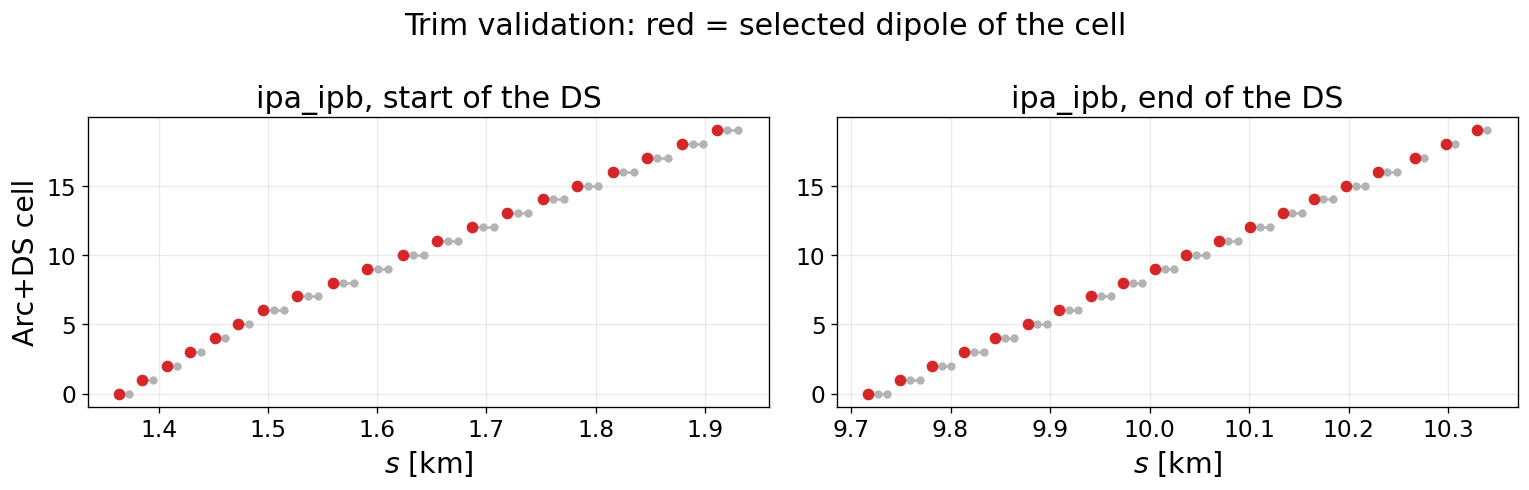

In [37]:
print(f"BPMs: {len(monitor_names)}")
print(f"Horizontal dipole trims: {len(trim_dipole_names)}")
display(selection_summary)
display(trim_layout.head(12))

# Visual check: within every row, the red point must be the dipole that
# TRIM_INDEX_IN_CELL prescribes among the ordered dipoles of the cell shown
# in grey, for the size of that cell.
dipole_columns = [
    name for name in trim_layout.columns if name.startswith("dipole_")
]
first_sector = trim_layout['sector'].iloc[0]
sector_layout = trim_layout[trim_layout['sector'] == first_sector]
panels = {
    'start of the DS': sector_layout.head(20),
    'end of the DS': sector_layout.tail(20),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (panel_label, panel_rows) in zip(axes, panels.items()):
    for row_number, (_, row) in enumerate(panel_rows.iterrows()):
        names = [row[name] for name in dipole_columns if isinstance(row[name], str)]
        s_cell = np.asarray(tt.s[tt.rows.indices[names]], dtype=float) / 1e3
        ax.plot(s_cell, np.full(len(names), row_number), 'o-', color='0.7', ms=4)
        ax.plot(
            s_cell[int(row['position_in_cell']) - 1],
            row_number,
            'o',
            color='tab:red',
            ms=6,
        )
    ax.set_xlabel(r'$s$ [km]')
    ax.set_title(f'{first_sector}, {panel_label}')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Arc+DS cell')
fig.suptitle('Trim validation: red = selected dipole of the cell')
fig.tight_layout()
plt.show()

In [38]:
def build_horizontal_response_matrix(twiss, monitor_names, trim_dipole_names):
    monitor_indices = twiss.rows.indices[list(monitor_names)]
    trim_indices = twiss.rows.indices[list(trim_dipole_names)]

    beta_monitor = np.asarray(twiss.betx[monitor_indices], dtype=float)
    beta_trim = np.asarray(twiss.betx[trim_indices], dtype=float)
    mu_monitor = np.asarray(twiss.mux[monitor_indices], dtype=float)
    mu_trim = np.asarray(twiss.mux[trim_indices], dtype=float)
    tune = float(twiss.qx)

    beta_product = beta_monitor[:, None] * beta_trim[None, :]
    phase_difference = np.abs(mu_monitor[:, None] - mu_trim[None, :])

    return (
        np.sqrt(beta_product)
        / (2.0 * np.sin(np.pi * tune))
        * np.cos(np.pi * tune - 2.0 * np.pi * phase_difference)
    )


def correct_horizontal_orbit_with_dipole_trims(
    line,
    reference,
    monitor_names,
    trim_dipole_names,
    trim_base_knl,
    tolerance_rms_m=1e-6,
    max_iterations=10,
    gain=1.0,
    regularization=1e-3,
    solver_max_iterations=400,
):
    response = build_horizontal_response_matrix(
        reference,
        monitor_names,
        trim_dipole_names,
    )

    # Normalize columns so the regularization treats all trim locations fairly.
    column_scale = np.linalg.norm(response, axis=0)
    column_scale[column_scale == 0.0] = 1.0
    response_scaled = response / column_scale[None, :]

    reference_indices = reference.rows.indices[list(monitor_names)]
    reference_x = np.asarray(reference.x[reference_indices], dtype=float)
    history = []
    total_trim_kicks = np.zeros(len(trim_dipole_names), dtype=float)

    for iteration in range(max_iterations + 1):
        twiss_orbit = line.twiss(only_orbit=True)
        orbit_indices = twiss_orbit.rows.indices[list(monitor_names)]
        residual = np.asarray(twiss_orbit.x[orbit_indices], dtype=float) - reference_x

        rms_residual = float(np.sqrt(np.mean(residual**2)))
        maximum_residual = float(np.max(np.abs(residual)))

        history.append({
            "iteration": iteration,
            "x_rms_m": rms_residual,
            "x_max_m": maximum_residual,
        })

        print(
            f"Iteration {iteration}: x RMS = {rms_residual * 1e6:.4f} um, "
            f"max = {maximum_residual * 1e6:.4f} um"
        )

        if rms_residual <= tolerance_rms_m:
            print("Horizontal orbit correction converged.")
            break

        if iteration == max_iterations:
            print("Maximum number of iterations reached.")
            break

        solution = lsmr(
            response_scaled,
            -residual,
            damp=regularization,
            atol=1e-11,
            btol=1e-11,
            maxiter=solver_max_iterations,
        )
        delta_kick = gain * solution[0] / column_scale

        total_trim_kicks += delta_kick
        set_horizontal_dipole_trim_kicks(
            line,
            trim_dipole_names,
            trim_base_knl,
            total_trim_kicks,
        )

        applied_kicks = total_trim_kicks
        print(
            f"  LSMR iterations = {solution[2]}, "
            f"linear residual norm = {solution[3] * 1e6:.4f} um, "
            f"step RMS = {1e6 * np.sqrt(np.mean(delta_kick**2)):.4f} urad, "
            f"total trim RMS = {1e6 * np.sqrt(np.mean(applied_kicks**2)):.4f} urad"
        )

    return pd.DataFrame(history), response, total_trim_kicks

In [39]:
trim_correction_history, trim_response_matrix, trim_kicks_rad = (
    correct_horizontal_orbit_with_dipole_trims(
        line=line,
        reference=twiss_ideal,
        monitor_names=monitor_names,
        trim_dipole_names=trim_dipole_names,
        trim_base_knl=trim_base_knl,
        tolerance_rms_m=1e-6,       # 1 um BPM RMS
        max_iterations=100,
        gain=1.0,
        regularization=1e-6,
        solver_max_iterations=400,
    )
)

display(trim_correction_history)

Iteration 0: x RMS = 232.4883 um, max = 856.8730 um
  LSMR iterations = 400, linear residual norm = 736.8069 um, step RMS = 5.2873 urad, total trim RMS = 5.2873 urad
Iteration 1: x RMS = 101.1313 um, max = 609.5558 um
  LSMR iterations = 400, linear residual norm = 366.2108 um, step RMS = 0.5481 urad, total trim RMS = 4.8527 urad
Iteration 2: x RMS = 65.1032 um, max = 326.6095 um
  LSMR iterations = 400, linear residual norm = 243.6555 um, step RMS = 0.5362 urad, total trim RMS = 4.5967 urad
Iteration 3: x RMS = 59.7634 um, max = 327.0226 um
  LSMR iterations = 400, linear residual norm = 206.7799 um, step RMS = 0.2701 urad, total trim RMS = 4.5058 urad
Iteration 4: x RMS = 21.7972 um, max = 130.3456 um
  LSMR iterations = 400, linear residual norm = 135.0969 um, step RMS = 0.3362 urad, total trim RMS = 4.3824 urad
Iteration 5: x RMS = 16.8665 um, max = 90.9583 um
  LSMR iterations = 400, linear residual norm = 113.5917 um, step RMS = 0.1728 urad, total trim RMS = 4.3419 urad
Iteration

,iteration,x_rms_m,x_max_m
0,0,0.000232,0.000857
1,1,0.000101,0.000610
2,2,0.000065,0.000327
3,3,0.000060,0.000327
4,4,0.000022,0.000130
...,...,...,...
96,96,0.000001,0.000039
97,97,0.000001,0.000039
98,98,0.000001,0.000039
99,99,0.000001,0.000039


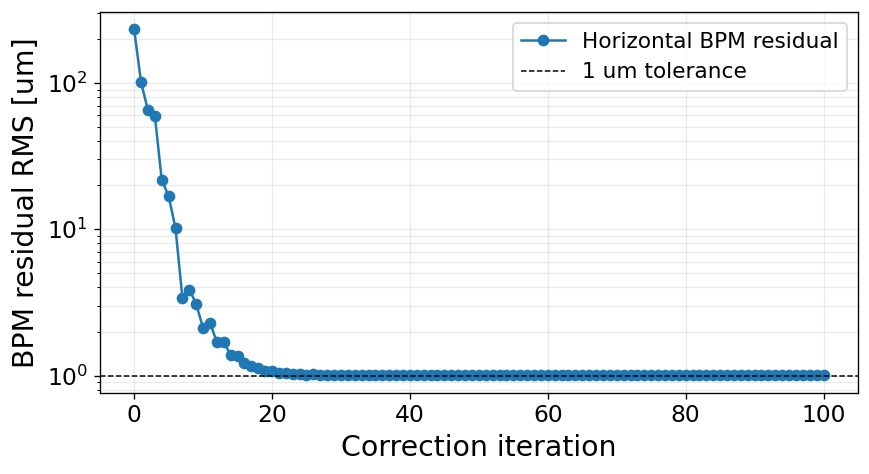

In [40]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(
    trim_correction_history['iteration'],
    1e6 * trim_correction_history['x_rms_m'],
    'o-',
    label='Horizontal BPM residual',
)
ax.axhline(1.0, color='black', ls='--', lw=0.9, label='1 um tolerance')
ax.set_xlabel('Correction iteration')
ax.set_ylabel('BPM residual RMS [um]')
ax.grid(alpha=0.25, which='both')
ax.legend()
fig.tight_layout()
plt.show()

In [41]:
get_rf_phase(line)
rf_phase_corrected = read_rf_phase(line)
rf_phase_corrected

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.102984,-63.196317
1,rf800.0,4020.0,-1.102786,-63.184958
2,rf800.1,4020.0,-1.102786,-63.184958
3,rf400.1,990.0,-1.102984,-63.196317


In [42]:
twiss_after_dipole_trims = line.twiss(
    eneloss_and_damping=True,
    radiation_analysis=True,
)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


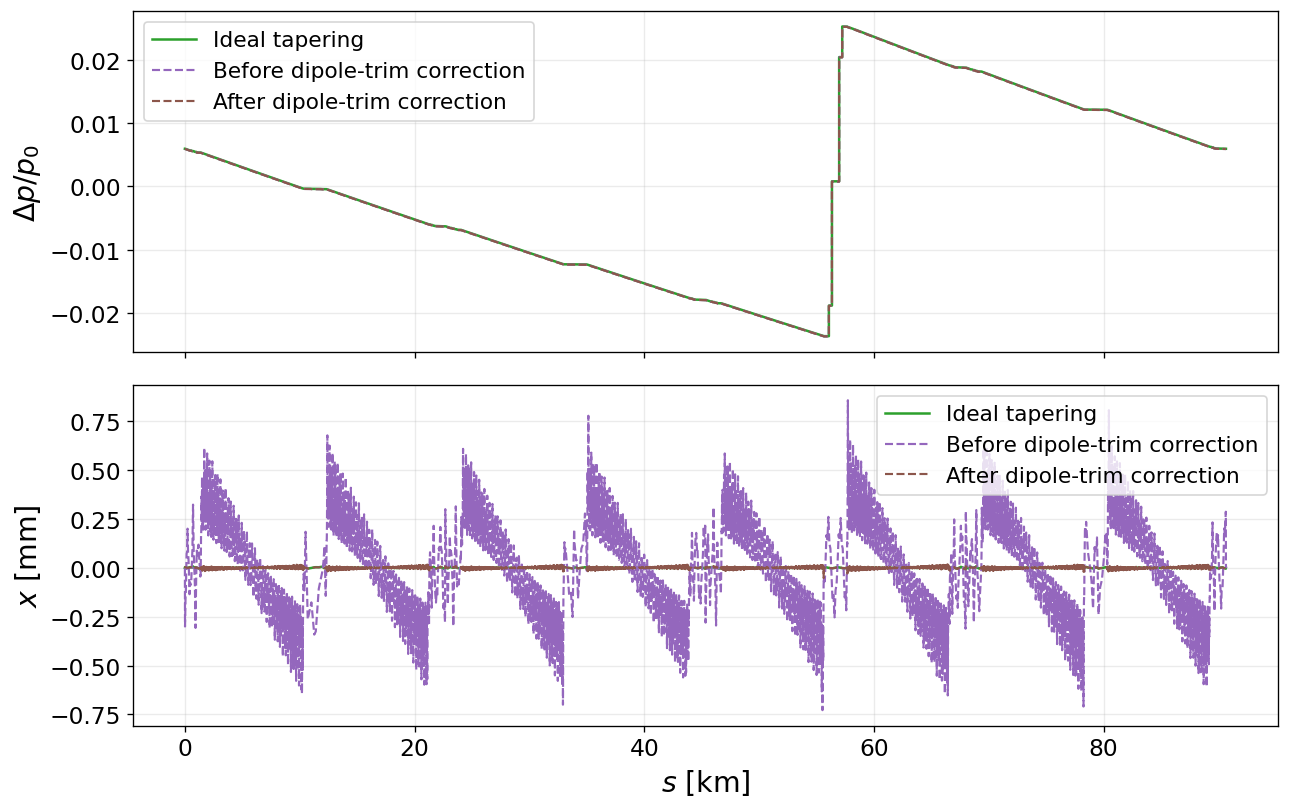

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[0].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[0].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.delta,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[0].set_ylabel(r"$\Delta p/p_0$")
axes[0].legend()

axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[1].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[1].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.x * 1e3,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"$x$ [mm]")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

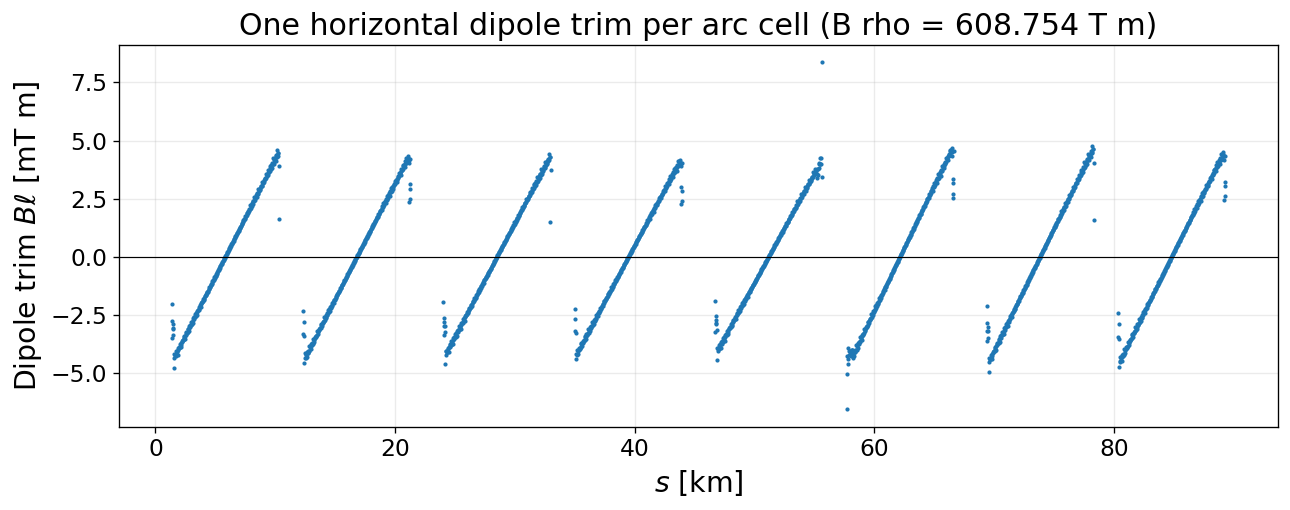

Trims: 2262
RMS kick = 4.23464 urad
Max |kick| = 13.7403 urad
RMS |B*l| = 2.57786 mT m
Max |B*l| = 8.36447 mT m


In [44]:
p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
charge_number = abs(float(line.particle_ref.q0))
magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)
trim_integrated_field_mTm = trim_kicks_rad * magnetic_rigidity_Tm * 1e3
trim_s_km = trim_layout['s_km'].to_numpy(float)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trim_s_km, trim_integrated_field_mTm, '.', ms=3)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel(r'Dipole trim $B\ell$ [mT m]')
ax.grid(alpha=0.25)
ax.set_title(
    f'One horizontal dipole trim per arc cell '
    f'(B rho = {magnetic_rigidity_Tm:.3f} T m)'
)
fig.tight_layout()
plt.show()

print(f'Trims: {len(trim_kicks_rad)}')
print(f'RMS kick = {1e6 * np.sqrt(np.mean(trim_kicks_rad**2)):.6g} urad')
print(f'Max |kick| = {1e6 * np.max(np.abs(trim_kicks_rad)):.6g} urad')
print(f'RMS |B*l| = {np.sqrt(np.mean(trim_integrated_field_mTm**2)):.6g} mT m')
print(f'Max |B*l| = {np.max(np.abs(trim_integrated_field_mTm)):.6g} mT m')

# Summary

In [45]:
twiss_scenario_2_before_correction = twiss_quad_sext
twiss_scenario_2_after_correction = twiss_after_dipole_trims

In [46]:
beta_beating_x = (
    twiss_scenario_2_after_correction.betx - twiss_ideal.betx
) / twiss_ideal.betx

beta_beating_y = (
    twiss_scenario_2_after_correction.bety - twiss_ideal.bety
) / twiss_ideal.bety


diagnostics = pd.DataFrame({
    "name": np.asarray(twiss_scenario_2_after_correction.name, dtype=str),
    "s_km": np.asarray(twiss_scenario_2_after_correction.s) / 1e3,
    "beta_beating_x": beta_beating_x,
    "beta_beating_y": beta_beating_y,
    "orbit_x_mm": (
        twiss_scenario_2_after_correction.x - twiss_ideal.x
    ) * 1e3,
})


print("Largest horizontal beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_x))[-15:]
    ].sort_values(
        "beta_beating_x",
        key=np.abs,
        ascending=False,
    )
)


print("Largest vertical beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_y))[-15:]
    ].sort_values(
        "beta_beating_y",
        key=np.abs,
        ascending=False,
    )
)

Largest horizontal beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
20593,||drift_36::2438,62.245156,0.011065,0.002279,1.280431e-04
20594,qd1a.595,62.245306,0.011056,0.002260,1.187041e-04
28105,||drift_78::806,84.910220,0.010595,0.001414,1.198365e-04
28106,qd1a.811,84.910370,0.010586,0.001396,1.110986e-04
20595,||drift_34::893,62.247166,0.010546,0.002128,5.970548e-06
20599,sd1a.281,62.247266,0.010498,0.002127,-2.424126e-09
20597,hcor_qd1a.595,62.247266,0.010498,0.002127,-2.424126e-09
20596,bpm_qd1a.595,62.247266,0.010498,0.002127,-2.424126e-09
20598,vcor_qd1a.595,62.247266,0.010498,0.002127,-2.424126e-09
24555,qd1a.703,73.934770,0.010346,0.001213,1.152152e-04


Largest vertical beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
22589,||drift_78::103,68.105533,0.001061,-0.010833,-7.309447e-04
22590,qd4r.3,68.105683,0.001003,-0.010318,-7.327639e-04
20879,||drift_36::2485,62.983716,-0.006638,0.007766,-1.462174e-03
20880,mbd.4638,62.983866,-0.006643,0.007763,-1.531873e-03
20703,qf2a.587,62.532736,-0.008226,0.007749,6.557043e-04
20702,||drift_36::2456,62.532586,-0.008222,0.007746,6.869682e-04
20582,||drift_34::892,62.215696,0.000378,0.007569,4.656098e-06
20586,sf1a.281,62.215796,0.000400,0.007563,2.779880e-09
20583,bpm_qf2a.583,62.215796,0.000400,0.007563,2.779880e-09
20584,hcor_qf2a.583,62.215796,0.000400,0.007563,2.779880e-09


In [47]:
def twiss_scalar(twiss, *candidate_names):
    for name in candidate_names:
        value = getattr(twiss, name, None)
        if value is not None:
            array = np.asarray(value)
            if array.size:
                return float(array.reshape(-1)[0])
    return np.nan

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values**2)))

def max_abs(values):
    return float(np.nanmax(np.abs(np.asarray(values, dtype=float))))

def percent_change(value, reference):
    if not np.isfinite(reference) or reference == 0:
        return np.nan
    return 100.0 * (value/reference - 1.0)

def complete_optics_summary(twiss, reference):
    betx_beating = (twiss.betx-reference.betx)/reference.betx
    bety_beating = (twiss.bety-reference.bety)/reference.bety
    delta_x = twiss.x-reference.x
    delta_y = twiss.y-reference.y
    delta_dx = twiss.dx-reference.dx
    delta_dy = twiss.dy-reference.dy

    emit_x = twiss_scalar(twiss, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y = twiss_scalar(twiss, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')
    emit_x_ref = twiss_scalar(reference, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y_ref = twiss_scalar(reference, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')

    return {
        'Horizontal tune Qx': twiss_scalar(twiss, 'qx'),
        'Vertical tune Qy': twiss_scalar(twiss, 'qy'),
        'Horizontal tune shift': twiss_scalar(twiss, 'qx')-twiss_scalar(reference, 'qx'),
        'Vertical tune shift': twiss_scalar(twiss, 'qy')-twiss_scalar(reference, 'qy'),
        'Horizontal chromaticity Qx_prime': twiss_scalar(twiss, 'dqx'),
        'Vertical chromaticity Qy_prime': twiss_scalar(twiss, 'dqy'),
        'Minimum tune separation |C-|': twiss_scalar(twiss, 'c_minus'),
        'Synchrotron tune Qs': twiss_scalar(twiss, 'qs'),
        'RMS beta-x beating [%]': 100*rms(betx_beating),
        'Maximum beta-x beating [%]': 100*max_abs(betx_beating),
        'RMS beta-y beating [%]': 100*rms(bety_beating),
        'Maximum beta-y beating [%]': 100*max_abs(bety_beating),
        'RMS horizontal-orbit residual [um]': 1e6*rms(delta_x),
        'Maximum horizontal-orbit residual [um]': 1e6*max_abs(delta_x),
        'RMS vertical-orbit residual [um]': 1e6*rms(delta_y),
        'Maximum vertical-orbit residual [um]': 1e6*max_abs(delta_y),
        'RMS horizontal-dispersion residual [mm]': 1e3*rms(delta_dx),
        'Maximum horizontal-dispersion residual [mm]': 1e3*max_abs(delta_dx),
        'RMS vertical-dispersion residual [mm]': 1e3*rms(delta_dy),
        'Maximum vertical-dispersion residual [mm]': 1e3*max_abs(delta_dy),
        'Equilibrium horizontal emittance [nm]': 1e9*emit_x,
        'Horizontal emittance change [%]': percent_change(emit_x, emit_x_ref),
        'Equilibrium vertical emittance [pm]': 1e12*emit_y,
        'Vertical emittance change [%]': percent_change(emit_y, emit_y_ref),
        'Equilibrium longitudinal emittance [um]': 1e6*twiss_scalar(
            twiss, 'eq_gemitt_zeta', 'rad_int_eq_gemitt_zeta'),
        'Equilibrium momentum spread [%]': 100*twiss_scalar(
            twiss, 'eq_sigma_delta', 'rad_int_sigma_delta'),
        'Equilibrium bunch length [mm]': 1e3*twiss_scalar(
            twiss, 'eq_sigma_zeta', 'eq_sigma_z', 'rad_int_sigma_zeta'),
        'Energy loss per turn [GeV]': 1e-9*twiss_scalar(
            twiss, 'eneloss_turn', 'rad_int_energy_loss'),
        'Momentum compaction factor': twiss_scalar(
            twiss, 'momentum_compaction_factor'),
        'Slip factor': twiss_scalar(twiss, 'slip_factor'),
    }

optics_comparison = pd.DataFrame({
    'Ideal tapering': complete_optics_summary(twiss_ideal, twiss_ideal),
    'Scenario 2 before correction': complete_optics_summary(
        twiss_scenario_2_before_correction, twiss_ideal),
    'Scenario 2 after dipole-trim correction': complete_optics_summary(
        twiss_after_dipole_trims, twiss_ideal),
})
pd.set_option('display.max_rows', None)
display(optics_comparison)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:3761: FutureWarning: `eneloss_turn` is deprecated, use `energy_loss` instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn(object.__getattribute__(self, '_DEPRECATED_FIELDS')[name], FutureWarning)


,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Horizontal tune Qx,3.461316e+02,3.461390e+02,3.461337e+02
Vertical tune Qy,2.622813e+02,2.622783e+02,2.622831e+02
Horizontal tune shift,0.000000e+00,7.428041e-03,2.121668e-03
Vertical tune shift,0.000000e+00,-2.940671e-03,1.767965e-03
Horizontal chromaticity Qx_prime,4.605618e+00,4.539205e+00,4.589739e+00
Vertical chromaticity Qy_prime,3.873636e+00,3.722596e+00,3.845917e+00
Minimum tune separation |C-|,1.946384e-10,4.624362e-10,3.405864e-10
Synchrotron tune Qs,9.183682e-02,9.182624e-02,9.187144e-02
RMS beta-x beating [%],0.000000e+00,2.327265e+00,3.516369e-01
Maximum beta-x beating [%],0.000000e+00,6.359260e+00,1.106485e+00


In [48]:
# Focused equilibrium-emittance comparison.
emittance_rows = [
    'Equilibrium horizontal emittance [nm]',
    'Horizontal emittance change [%]',
    'Equilibrium vertical emittance [pm]',
    'Vertical emittance change [%]',
    'Equilibrium momentum spread [%]',
    'Equilibrium bunch length [mm]',
]
display(optics_comparison.loc[emittance_rows])

,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Equilibrium horizontal emittance [nm],2.189257,2.191176,2.188830
Horizontal emittance change [%],0.000000,0.087674,-0.019518
Equilibrium vertical emittance [pm],0.063788,0.063632,0.063908
Vertical emittance change [%],0.000000,-0.244381,0.189088
Equilibrium momentum spread [%],NaN,NaN,NaN
Equilibrium bunch length [mm],NaN,NaN,NaN


# Horizontal optics comparison for every case

The dispersion is compared directly with the ideal lattice. The beta beating is shown as the relative difference from the ideal horizontal beta function.

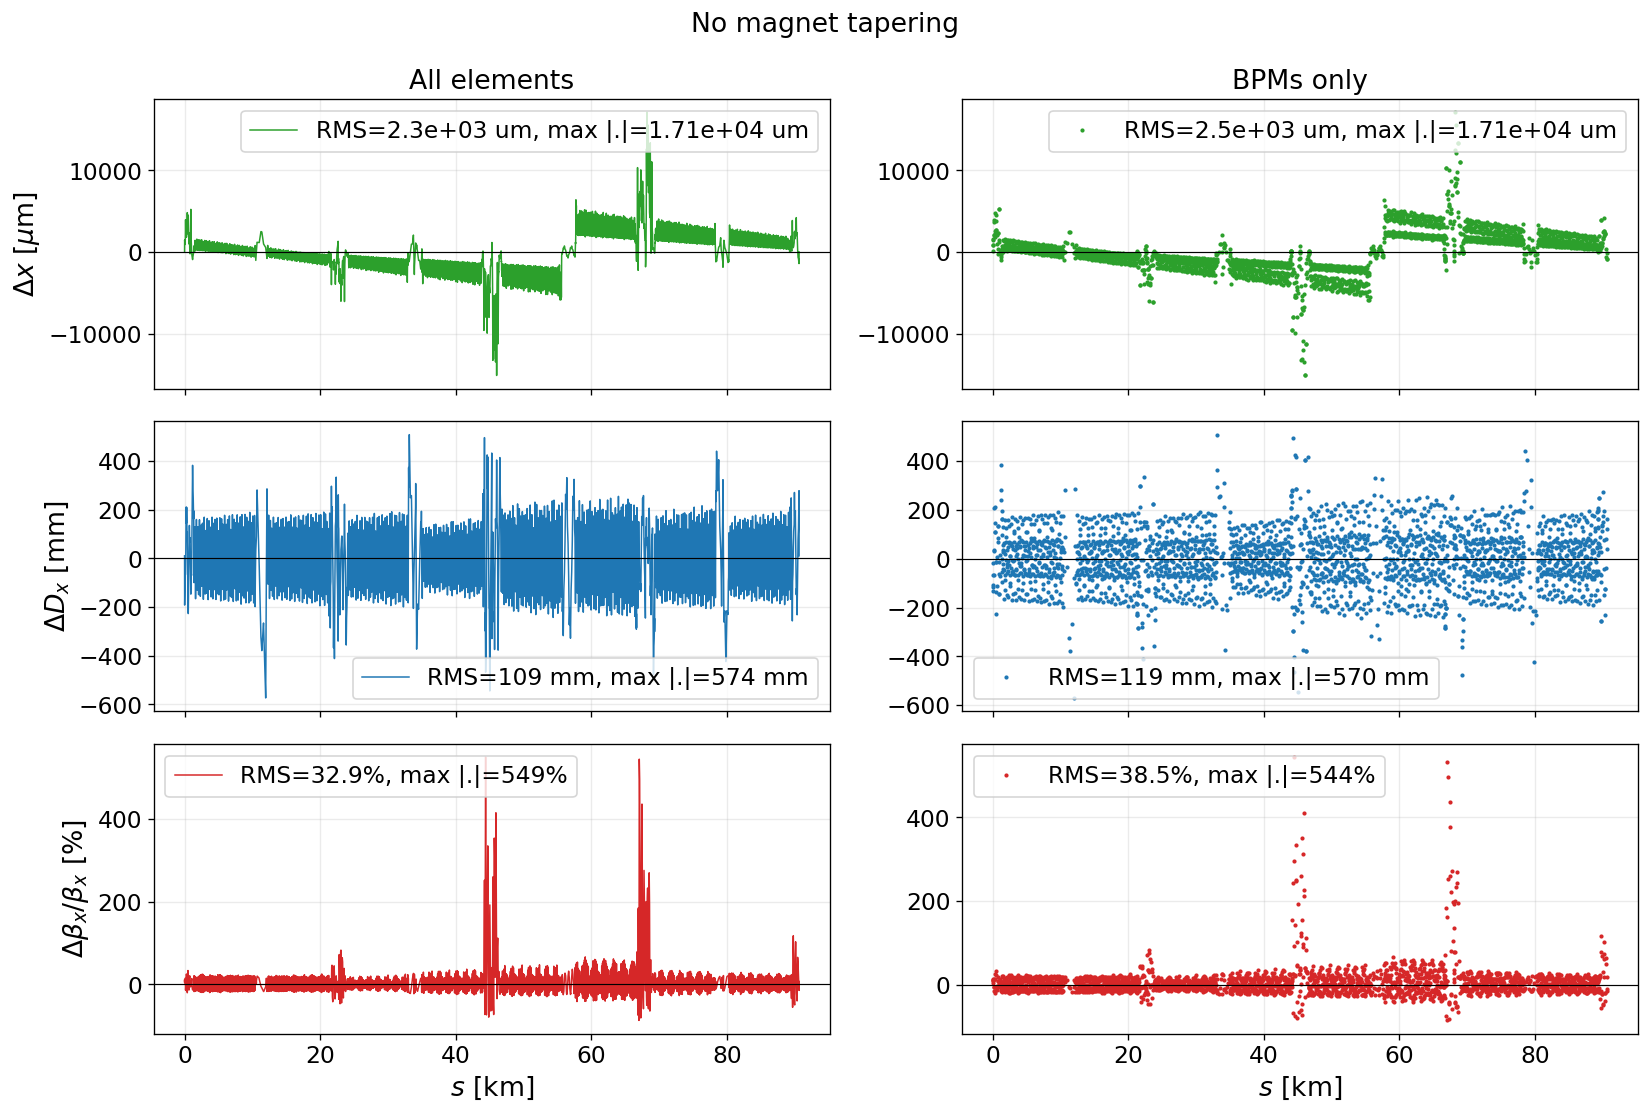

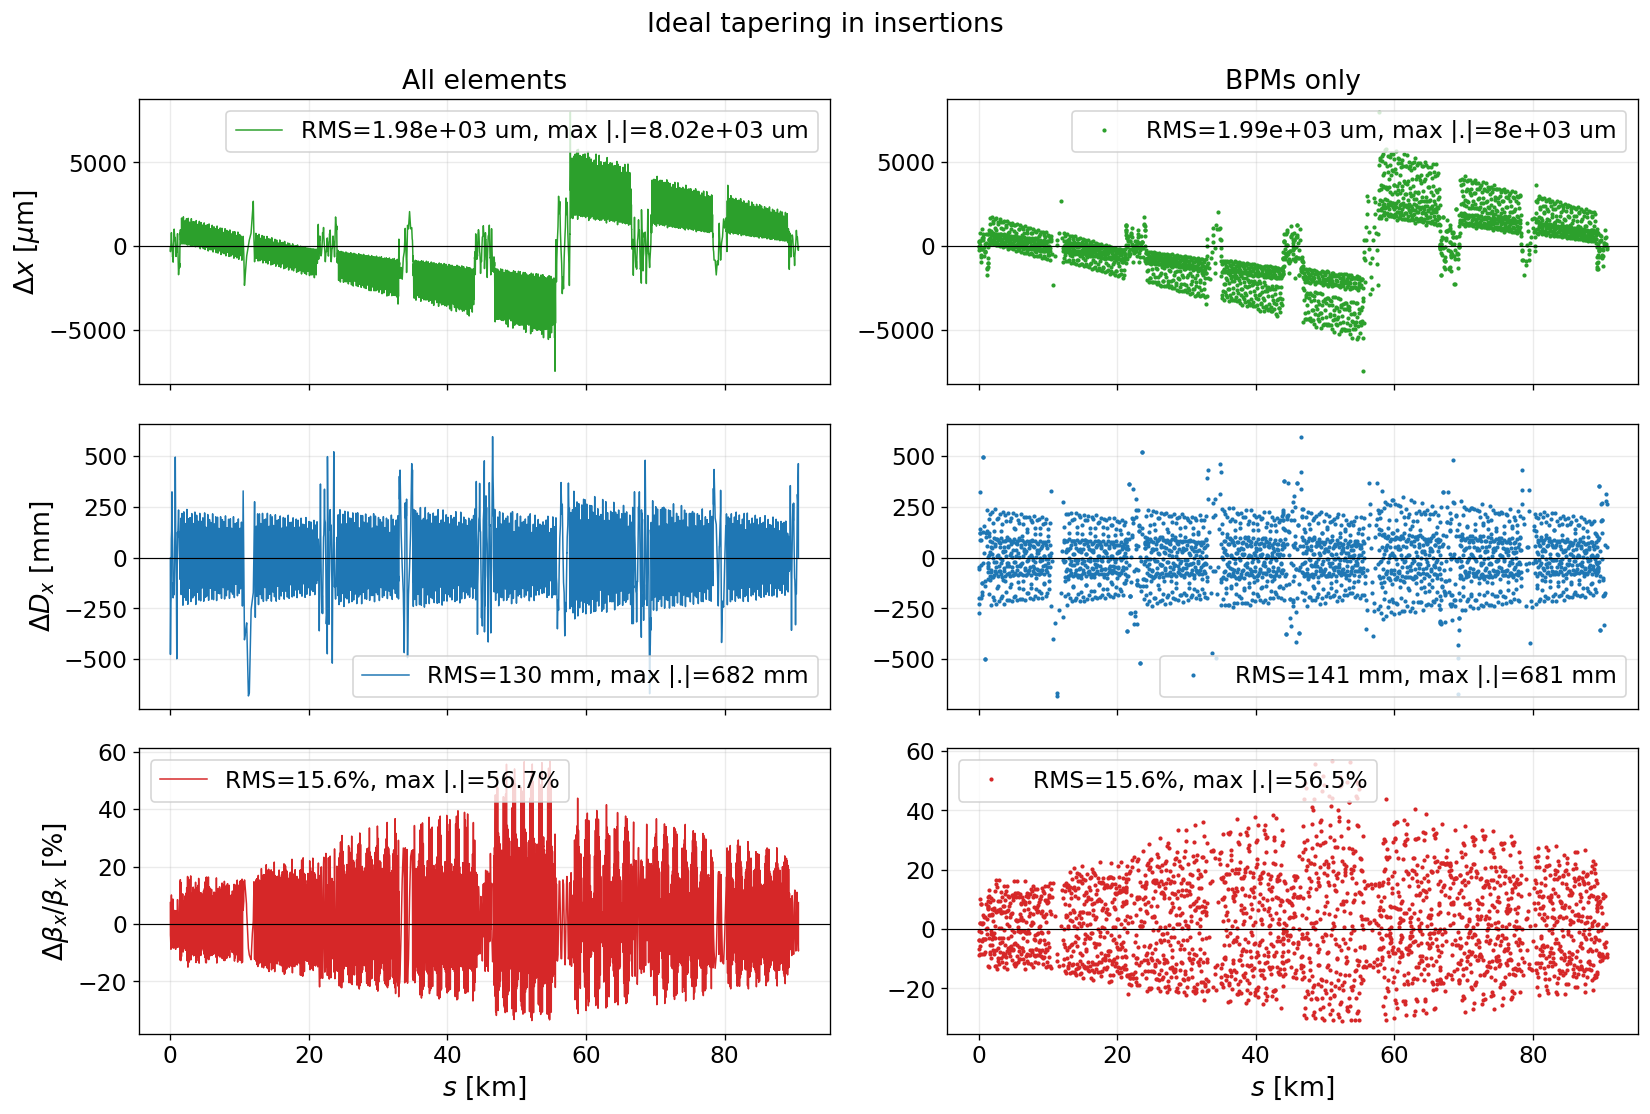

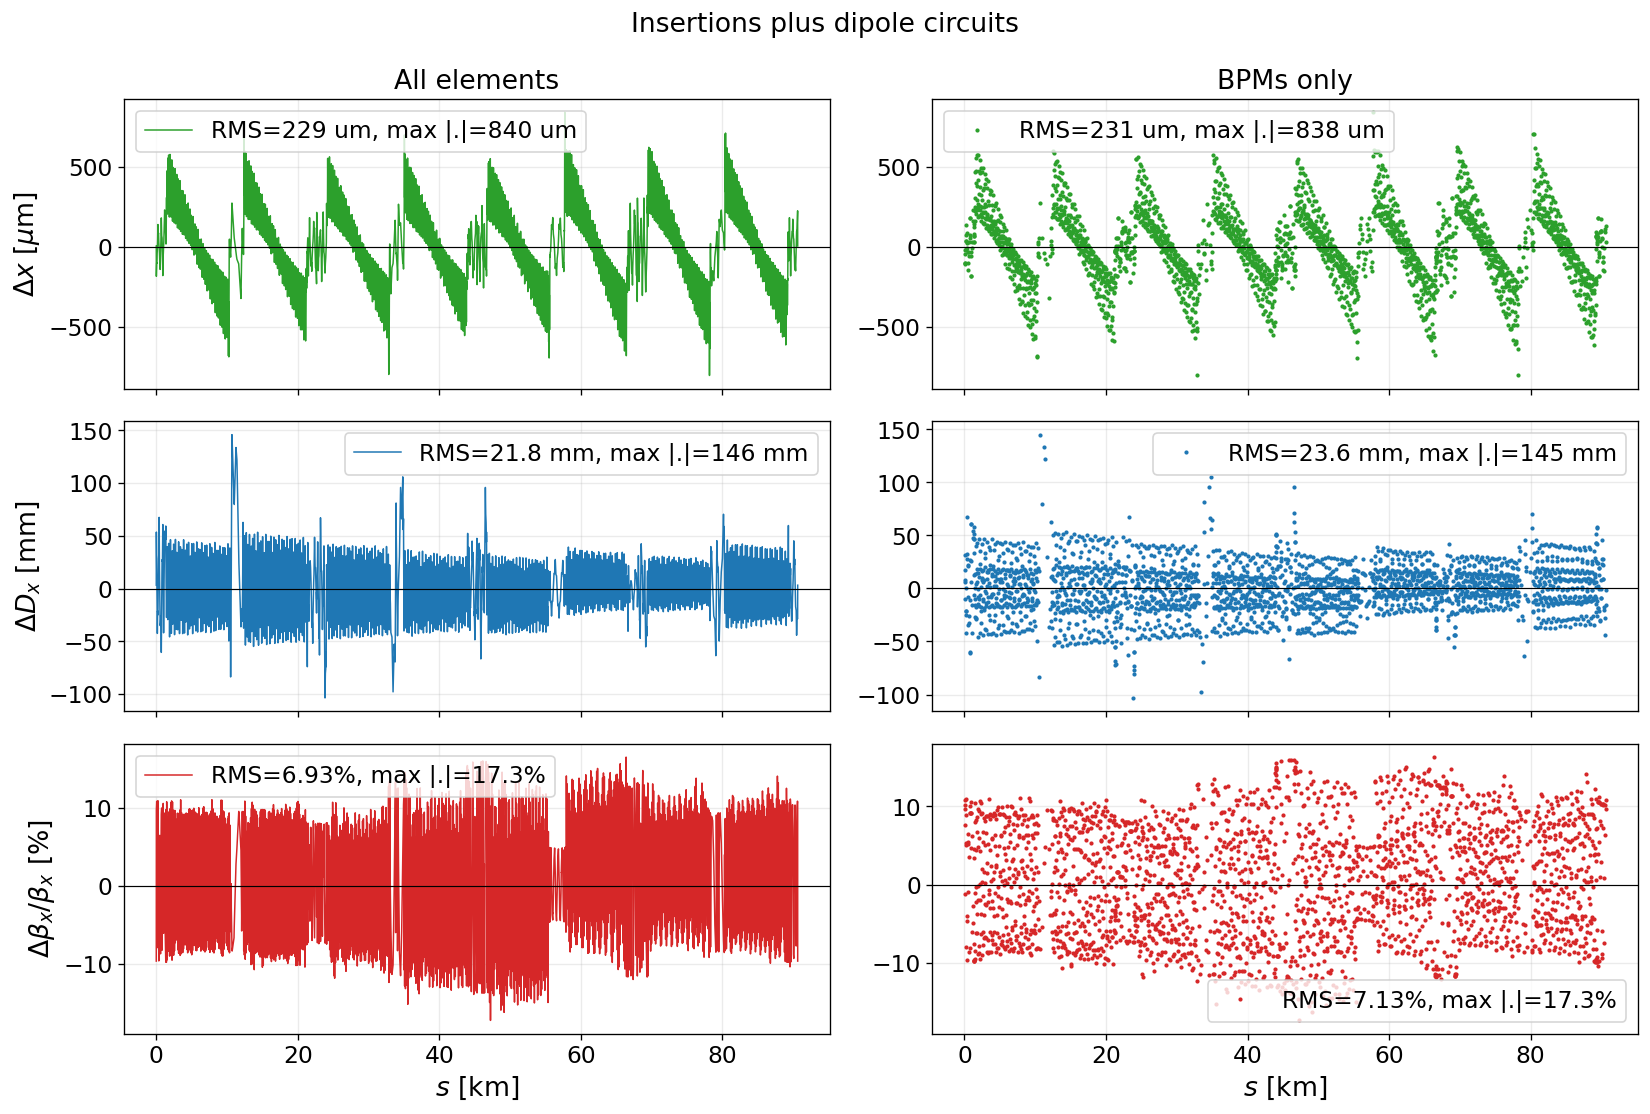

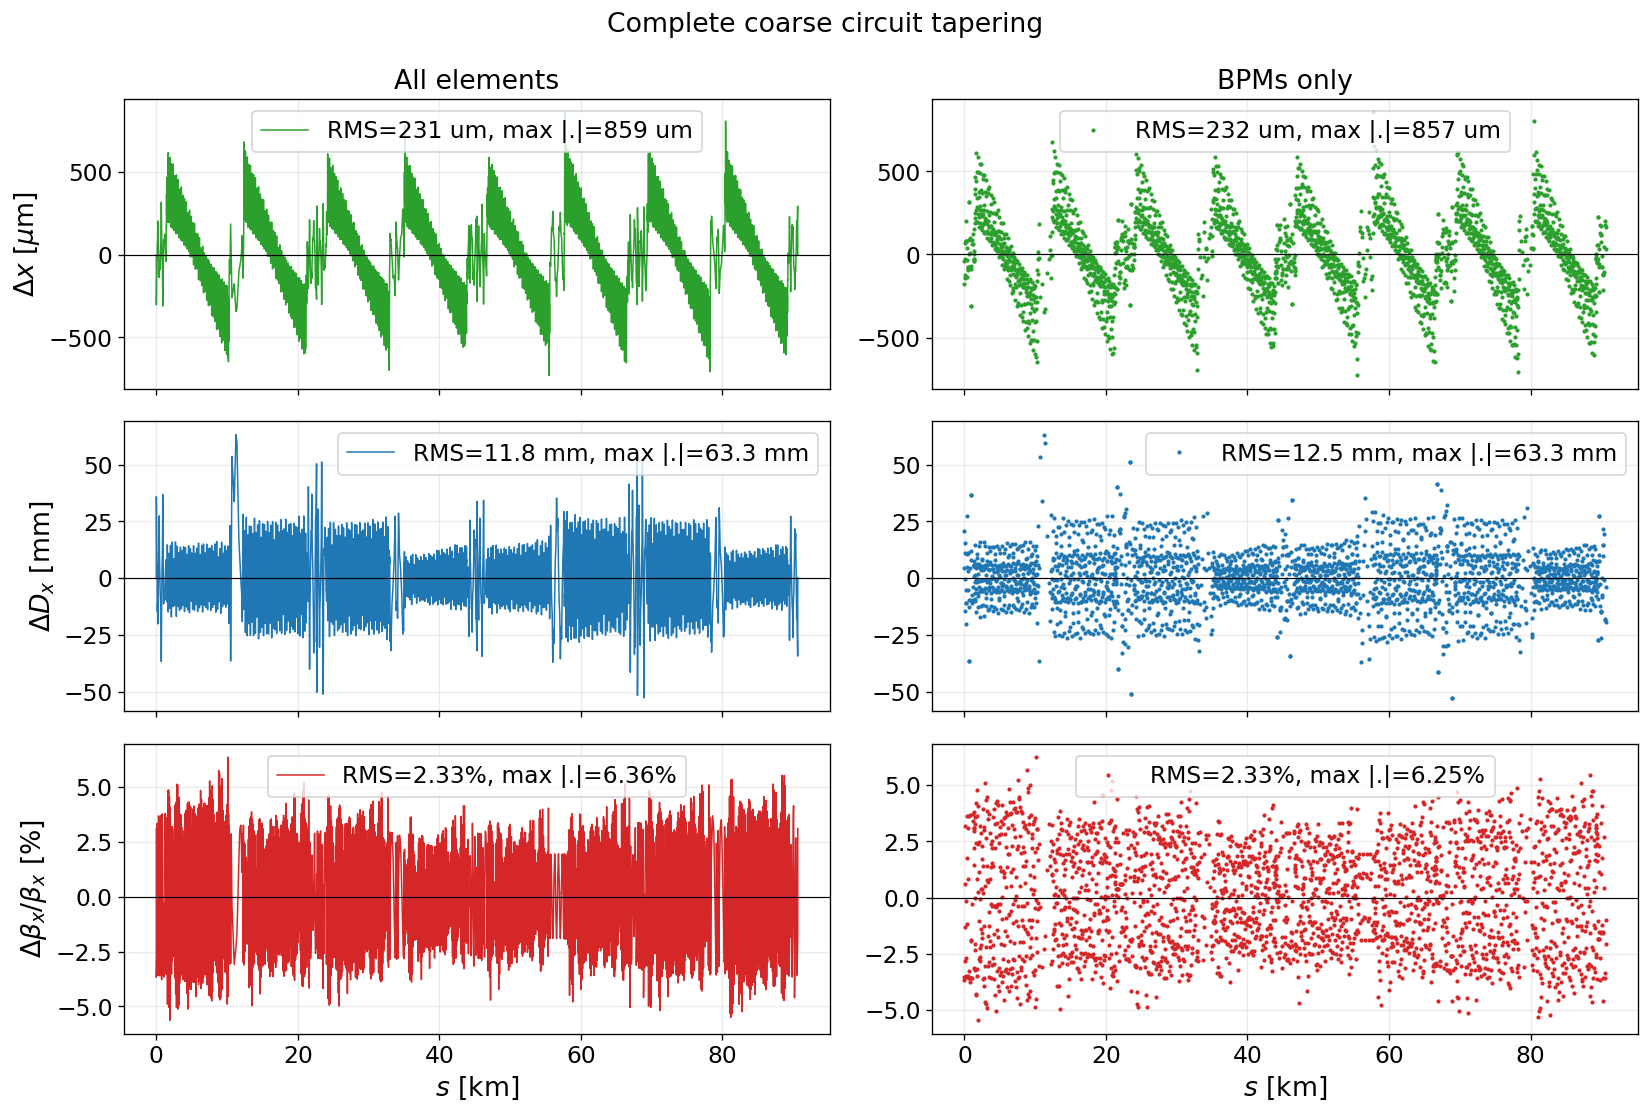

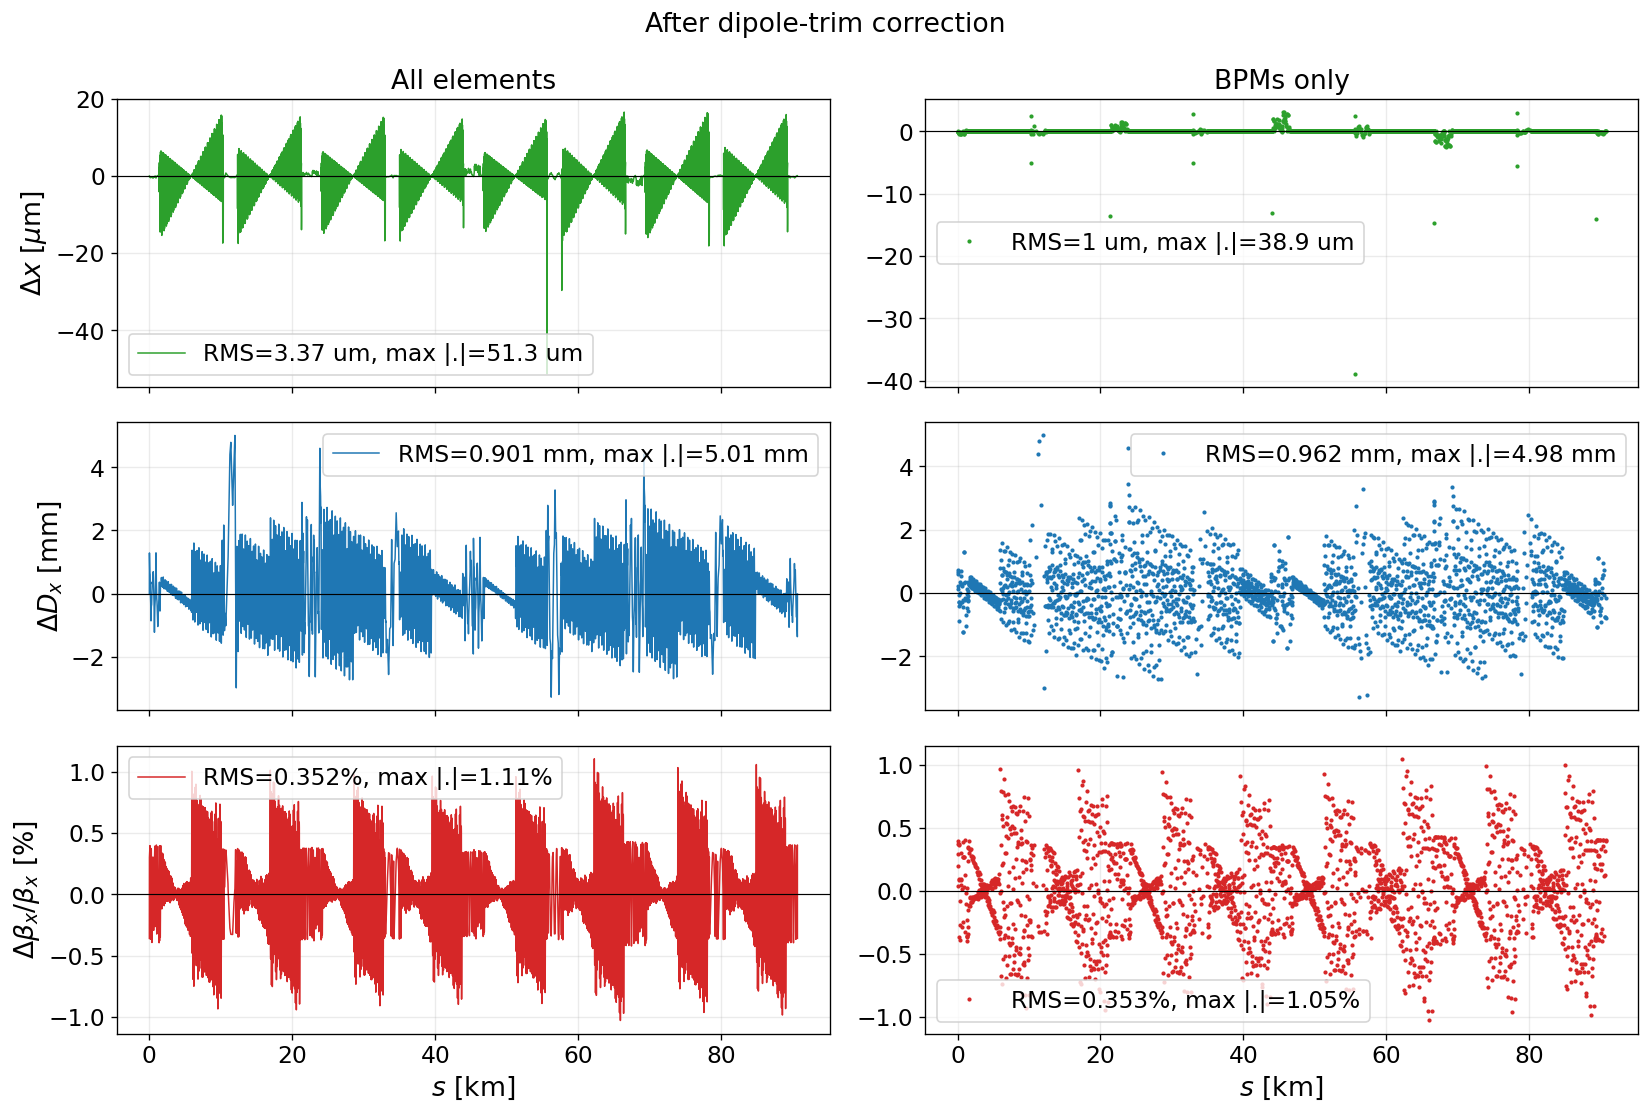

In [49]:
def plot_horizontal_optics_case(twiss_case, reference, label, bpm_names):
    bpm_names = list(np.asarray(bpm_names, dtype=str))

    # All Twiss locations
    s_all_km = np.asarray(reference.s, dtype=float) / 1e3
    delta_orbit_x_all_um = 1e6 * (
        np.asarray(twiss_case.x, dtype=float)
        - np.asarray(reference.x, dtype=float)
    )
    delta_dispersion_all_mm = 1e3 * (
        np.asarray(twiss_case.dx, dtype=float)
        - np.asarray(reference.dx, dtype=float)
    )
    beta_beating_all_percent = 100.0 * (
        np.asarray(twiss_case.betx, dtype=float)
        / np.asarray(reference.betx, dtype=float) - 1.0
    )

    # BPM locations only. Obtain the indices independently from each table.
    reference_bpm_indices = reference.rows.indices[bpm_names]
    case_bpm_indices = twiss_case.rows.indices[bpm_names]
    s_bpm_km = np.asarray(reference.s[reference_bpm_indices], dtype=float) / 1e3
    delta_orbit_x_bpm_um = 1e6 * (
        np.asarray(twiss_case.x[case_bpm_indices], dtype=float)
        - np.asarray(reference.x[reference_bpm_indices], dtype=float)
    )
    delta_dispersion_bpm_mm = 1e3 * (
        np.asarray(twiss_case.dx[case_bpm_indices], dtype=float)
        - np.asarray(reference.dx[reference_bpm_indices], dtype=float)
    )
    beta_beating_bpm_percent = 100.0 * (
        np.asarray(twiss_case.betx[case_bpm_indices], dtype=float)
        / np.asarray(reference.betx[reference_bpm_indices], dtype=float) - 1.0
    )

    def statistics(values):
        values = np.asarray(values, dtype=float)
        return np.sqrt(np.nanmean(values**2)), np.nanmax(np.abs(values))

    orbit_all_rms, orbit_all_max = statistics(delta_orbit_x_all_um)
    orbit_bpm_rms, orbit_bpm_max = statistics(delta_orbit_x_bpm_um)
    dx_all_rms, dx_all_max = statistics(delta_dispersion_all_mm)
    dx_bpm_rms, dx_bpm_max = statistics(delta_dispersion_bpm_mm)
    betx_all_rms, betx_all_max = statistics(beta_beating_all_percent)
    betx_bpm_rms, betx_bpm_max = statistics(beta_beating_bpm_percent)

    fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex='col')
    axes[0, 0].plot(s_all_km, delta_orbit_x_all_um, color='tab:green', lw=0.9,
                    label=f'RMS={orbit_all_rms:.3g} um, max |.|={orbit_all_max:.3g} um')
    axes[0, 1].plot(s_bpm_km, delta_orbit_x_bpm_um, '.', color='tab:green', ms=3,
                    label=f'RMS={orbit_bpm_rms:.3g} um, max |.|={orbit_bpm_max:.3g} um')
    axes[1, 0].plot(s_all_km, delta_dispersion_all_mm, color='tab:blue', lw=0.9,
                    label=f'RMS={dx_all_rms:.3g} mm, max |.|={dx_all_max:.3g} mm')
    axes[1, 1].plot(s_bpm_km, delta_dispersion_bpm_mm, '.', color='tab:blue', ms=3,
                    label=f'RMS={dx_bpm_rms:.3g} mm, max |.|={dx_bpm_max:.3g} mm')
    axes[2, 0].plot(s_all_km, beta_beating_all_percent, color='tab:red', lw=0.9,
                    label=f'RMS={betx_all_rms:.3g}%, max |.|={betx_all_max:.3g}%')
    axes[2, 1].plot(s_bpm_km, beta_beating_bpm_percent, '.', color='tab:red', ms=3,
                    label=f'RMS={betx_bpm_rms:.3g}%, max |.|={betx_bpm_max:.3g}%')

    axes[0, 0].set_title('All elements', fontsize=16)
    axes[0, 1].set_title('BPMs only', fontsize=16)
    axes[0, 0].set_ylabel(r'$\Delta x$ [$\mu$m]', fontsize=16)
    axes[1, 0].set_ylabel(r'$\Delta D_x$ [mm]', fontsize=16)
    axes[2, 0].set_ylabel(r'$\Delta\beta_x/\beta_x$ [%]', fontsize=16)
    axes[2, 0].set_xlabel(r'$s$ [km]', fontsize=16)
    axes[2, 1].set_xlabel(r'$s$ [km]', fontsize=16)

    for ax in axes.flat:
        ax.axhline(0.0, color='black', lw=0.7)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.legend(fontsize=14)

    fig.suptitle(label, fontsize=16)
    fig.tight_layout()
    plt.show()

case_twiss_tables = {
    'No magnet tapering': tw_no_taper,
    'Ideal tapering in insertions': twiss_insertion_taper,
    'Insertions plus dipole circuits': twiss_dipole,
    'Complete coarse circuit tapering': twiss_quad_sext,
    'After dipole-trim correction': twiss_after_dipole_trims,
}

for case_label, case_twiss in case_twiss_tables.items():
    plot_horizontal_optics_case(case_twiss, twiss_ideal, case_label, monitor_names)

# Dipole-trim distribution

In [50]:
# The trim integrated-field distribution was calculated above.
trim_strength_summary = pd.DataFrame({
    'dipole': trim_dipole_names,
    's_km': trim_s_km,
    'kick_urad': 1e6 * trim_kicks_rad,
    'length_m': trim_layout['length_m'].to_numpy(float),
    'integrated_field_mTm': trim_integrated_field_mTm,
})
trim_strength_summary["field mT"] = trim_strength_summary["integrated_field_mTm"] / trim_strength_summary["length_m"]
display(trim_strength_summary.head(12))

,dipole,s_km,kick_urad,length_m,integrated_field_mTm,field mT
0,mbd.0,1.363667,-3.336726,9.613334,-2.031247,-0.211295
1,mbd.2,1.385089,-5.748998,9.613334,-3.499728,-0.364049
2,mbd.4,1.407540,-4.516657,9.613334,-2.749535,-0.286013
3,mbd.6,1.428962,-5.062630,9.613334,-3.081899,-0.320586
4,mbd.8,1.451414,-4.785091,9.613334,-2.912945,-0.303011
5,mbd.10,1.472835,-5.096124,9.613334,-3.102288,-0.322707
6,mbd.12,1.495687,-5.546116,9.613334,-3.376223,-0.351202
7,mbd.15,1.526757,-7.874333,9.613334,-4.793535,-0.498634
8,mbd.18,1.559257,-6.894220,9.613334,-4.196887,-0.436569
9,mbd.21,1.590947,-7.174059,9.613334,-4.367240,-0.454290


Dipoles carrying both coarse field and trim winding: 2262


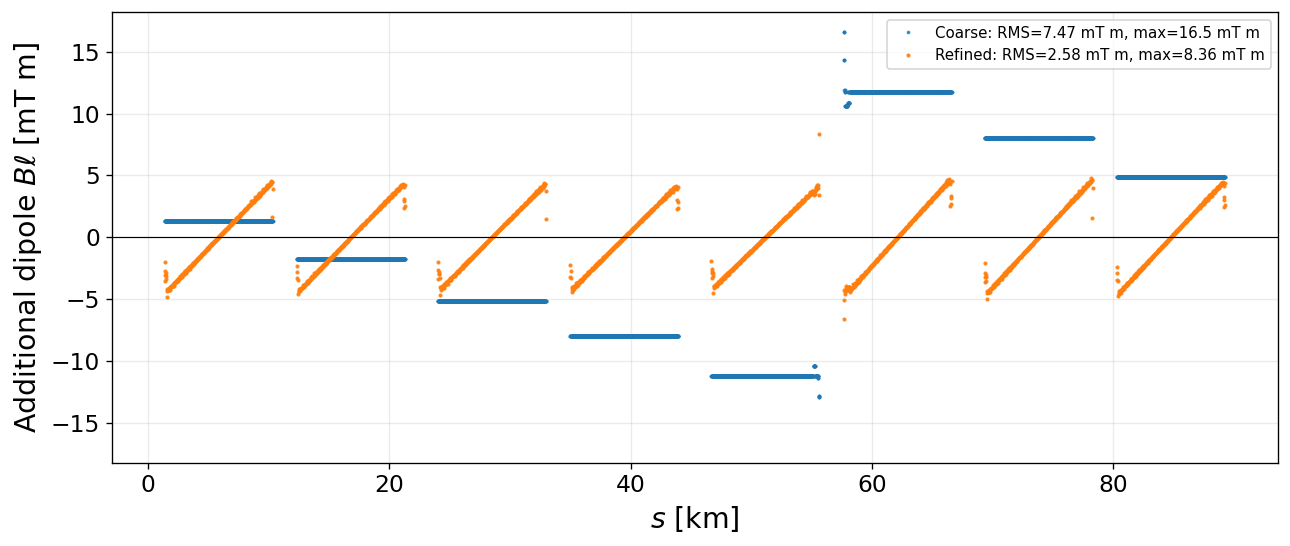

1 urad corresponds to 0.608754 mT m
Coarse dipoles: RMS |B*l| = 7.47117 mT m, max |B*l| = 16.547 mT m
Refined trims: RMS |B*l| = 2.57786 mT m, max |B*l| = 8.36447 mT m


,dipole,s_km,applied_delta_taper,integrated_field_mTm
0,mbd.0,1.363667,0.002448,1.298187
1,mbd.1,1.373315,0.002448,1.298187
1112,mbd.2,1.385089,0.002448,1.298187
2223,mbd.3,1.394737,0.002448,1.298187
3334,mbd.4,1.407540,0.002448,1.298187
4445,mbd.5,1.417189,0.002448,1.298187
5556,mbd.6,1.428962,0.002448,1.298187
6327,mbd.7,1.438610,0.002448,1.298187
6438,mbd.8,1.451414,0.002448,1.298187
6549,mbd.9,1.461062,0.002448,1.298187


In [51]:
# Compare the two arc+DS dipole contributions:
#   1. coarse field increment from delta_taper on every DIP_* circuit;
#   2. refined knl[0] trim field on one selected dipole per cell.
# The selected trim dipole can also belong to a coarse circuit, because the
# trim winding is superimposed on the main dipole field.
horizontal_integrated_field_mTm = trim_strength_summary["integrated_field_mTm"].to_numpy(float)

plot_table = line.get_table()
s_by_name = dict(zip(
    np.asarray(plot_table.name, dtype=str),
    np.asarray(plot_table.s, dtype=float),
))

# Derive this list locally so the cell has no hidden execution-order
# dependency on the older reserved-dipole implementation.
coarse_dipole_names = np.unique(np.concatenate([
    np.asarray(elements, dtype=str)
    for circuit_name, elements in circuits.items()
    if circuit_name.startswith("DIP_")
]))

coarse_rows = []
for name in np.asarray(coarse_dipole_names, dtype=str):
    element = line[name]
    length = float(getattr(element, "length", 0.0))
    k0 = getattr(element, "k0", "from_h")

    # For an RBend with k0='from_h', k0*L is represented by its bend angle.
    if isinstance(k0, str) and k0 == "from_h":
        normalized_integrated_strength = float(element.angle)
    else:
        normalized_integrated_strength = float(k0)*length

    coarse_rows.append({
        "dipole": name,
        "s_km": s_by_name[name]/1e3,
        "applied_delta_taper": float(element.delta_taper),
        "integrated_field_mTm": (
            1e3*magnetic_rigidity_Tm
            * normalized_integrated_strength
            * float(element.delta_taper)
        ),
    })

coarse_dipole_strength_summary = pd.DataFrame(coarse_rows).sort_values("s_km")
coarse_integrated_field_mTm = coarse_dipole_strength_summary["integrated_field_mTm"].to_numpy(float)

overlapping_dipoles = np.intersect1d(
    coarse_dipole_strength_summary["dipole"].to_numpy(str),
    trim_strength_summary["dipole"].to_numpy(str),
)
print(f"Dipoles carrying both coarse field and trim winding: "
      f"{len(overlapping_dipoles)}")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    coarse_dipole_strength_summary["s_km"],
    coarse_integrated_field_mTm,
    ".", ms=2.5, color="tab:blue", alpha=0.75,
    label=(f"Coarse: "
           f"RMS={np.sqrt(np.mean(coarse_integrated_field_mTm**2)):.3g} mT m, "
           f"max={np.max(np.abs(coarse_integrated_field_mTm)):.3g} mT m"),
)
ax.plot(
    trim_strength_summary["s_km"],
    horizontal_integrated_field_mTm,
    ".", ms=3.0, color="tab:orange", alpha=0.85,
    label=(f"Refined: "
           f"RMS={np.sqrt(np.mean(horizontal_integrated_field_mTm**2)):.3g} mT m, "
           f"max={np.max(np.abs(horizontal_integrated_field_mTm)):.3g} mT m"),
)
ax.axhline(0.0, color="black", lw=0.7)
ax.set_xlabel(r"$s$ [km]")
ax.set_ylabel(r"Additional dipole $B\ell$ [mT m]")
ax.grid(alpha=0.25)
#ax.set_title(
#    "Coarse and refined dipole integrated-field increments "
#    + rf"($B\rho={magnetic_rigidity_Tm:.3f}$ T m)"
#)
ax.legend(fontsize=9, loc="best")

combined_maximum = max(
    np.max(np.abs(coarse_integrated_field_mTm)),
    np.max(np.abs(horizontal_integrated_field_mTm)),
)
plot_limit = max(15.0, 1.10*combined_maximum)
ax.set_ylim(-plot_limit, plot_limit)
fig.tight_layout()
plt.show()

print(f"1 urad corresponds to {magnetic_rigidity_Tm*1e-3:.6g} mT m")
print(
    "Coarse dipoles: "
    f"RMS |B*l| = {np.sqrt(np.mean(coarse_integrated_field_mTm**2)):.6g} mT m, "
    f"max |B*l| = {np.max(np.abs(coarse_integrated_field_mTm)):.6g} mT m"
)
print(
    "Refined trims: "
    f"RMS |B*l| = {np.sqrt(np.mean(horizontal_integrated_field_mTm**2)):.6g} mT m, "
    f"max |B*l| = {np.max(np.abs(horizontal_integrated_field_mTm)):.6g} mT m"
)

display(coarse_dipole_strength_summary.head(12))


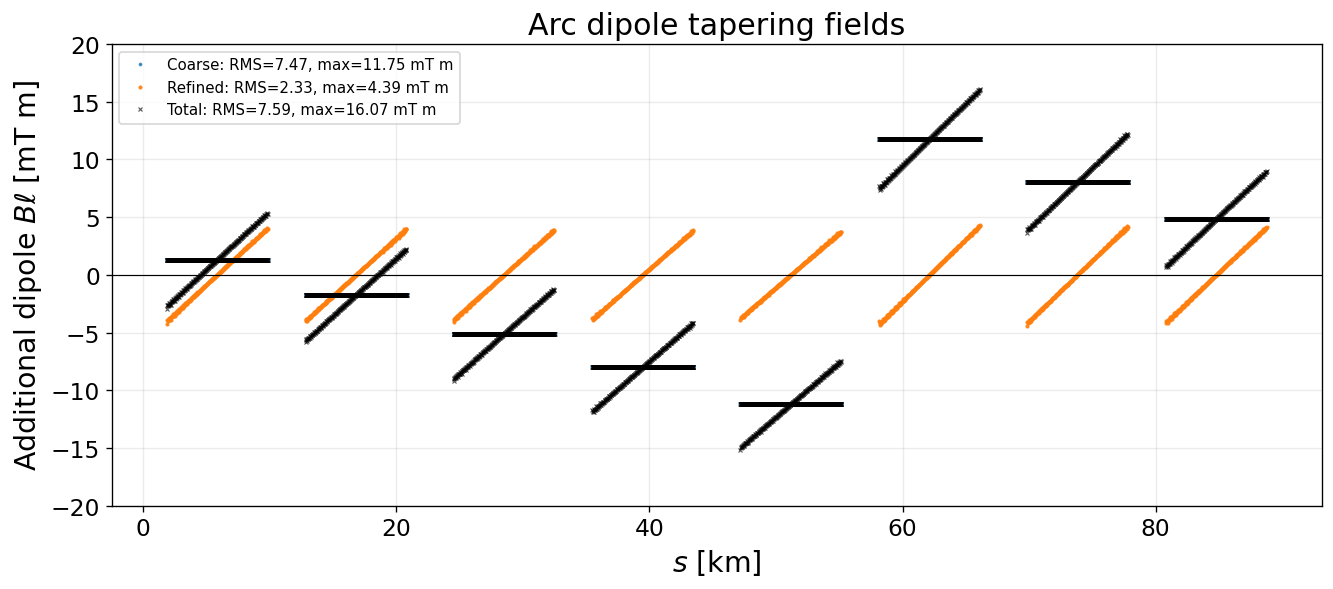

Coarse arc dipoles:  6000
Refined arc dipoles: 2000
Total arc dipoles:   6000


In [52]:
# Coarse, refined and total dipole-field contributions in the arcs only.
# Dispersion suppressors and insertions are excluded.

# TO FIX with 1+delta

arc_names = set(np.concatenate([
    np.asarray(names, dtype=str) for names in regions["arcs"].values()
]))

coarse_arcs = (
    coarse_dipole_strength_summary
    .loc[lambda frame: frame["dipole"].isin(arc_names),
         ["dipole", "s_km", "integrated_field_mTm"]]
    .sort_values("s_km")
)
refined_arcs = (
    trim_strength_summary
    .loc[lambda frame: frame["dipole"].isin(arc_names),
         ["dipole", "s_km", "integrated_field_mTm"]]
    .sort_values("s_km")
)

# Concatenation is clearer than an outer merge for the reserved-dipole
# layout. The groupby also remains correct if the two sets ever overlap.
total_arcs = (
    pd.concat([coarse_arcs, refined_arcs], ignore_index=True)
    .groupby("dipole", as_index=False)
    .agg(s_km=("s_km", "first"),
         integrated_field_mTm=("integrated_field_mTm", "sum"))
    .sort_values("s_km")
)

def rms_and_max(values):
    values = np.asarray(values, dtype=float)
    return np.sqrt(np.mean(values**2)), np.max(np.abs(values))

coarse_values = coarse_arcs["integrated_field_mTm"].to_numpy(float)
refined_values = refined_arcs["integrated_field_mTm"].to_numpy(float)
total_values = total_arcs["integrated_field_mTm"].to_numpy(float)
coarse_rms, coarse_max = rms_and_max(coarse_values)
refined_rms, refined_max = rms_and_max(refined_values)
total_rms, total_max = rms_and_max(total_values)

fig, ax = plt.subplots(figsize=(11, 4.8), layout="constrained")
ax.plot(coarse_arcs["s_km"], coarse_values, ".", ms=2.5,
        color="tab:blue", alpha=0.75,
        label=f"Coarse: RMS={coarse_rms:.2f}, max={coarse_max:.2f} mT m")
ax.plot(refined_arcs["s_km"], refined_values, ".", ms=3.0,
        color="tab:orange", alpha=0.85,
        label=f"Refined: RMS={refined_rms:.2f}, max={refined_max:.2f} mT m")
ax.plot(total_arcs["s_km"], total_values, "x", ms=2.5, mew=0.7,
        color="black", alpha=0.65,
        label=f"Total: RMS={total_rms:.2f}, max={total_max:.2f} mT m")
ax.axhline(0.0, color="black", lw=0.7)
ax.set(xlabel=r"$s$ [km]",
       ylabel=r"Additional dipole $B\ell$ [mT m]",
       title="Arc dipole tapering fields", ylim=(-20, 20))
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
plt.show()

print(f"Coarse arc dipoles:  {len(coarse_arcs)}")
print(f"Refined arc dipoles: {len(refined_arcs)}")
print(f"Total arc dipoles:   {len(total_arcs)}")


# Step 5: refine the optics with grouped arc+DS quadrupole trims
 
 this takes a lot of time, even if trims are grouped


In [53]:
from scipy.optimize import lsq_linear

QUADS_PER_TRIM_GROUP = 10             # if i don't group, very slow
MAX_RELATIVE_QUAD_TRIM = 0.01       # |Delta k1| <= 1% from tuning, already this i think it too much
DISPERSION_SCALE_M = 1e-3           # 1 mm
BETA_BEATING_SCALE = 0.01           # 1%
TUNE_SCALE = 1e-6
REGULARIZATION = 0.05


# this is focusing/defocusing grouping
def quadrupole_family(name):
    family = re.sub(r"\.\d+$", "", str(name).lower())
    if family.startswith("qf"):
        return "QF"
    if family.startswith("qd"):
        return "QD"
    return None


def make_quad_trim_groups(line, regions, group_size):
    table = line.get_table()
    element_type = dict(zip(np.asarray(table.name, str),
                            np.asarray(table.element_type, str)))
    s_by_name = dict(zip(np.asarray(table.name, str),
                         np.asarray(table.s, float)))
    rows = []

    # use quads in arcs and DS
    for sector, sector_elements in regions["arc_ds"].items():
        for family in ("QF", "QD"):
            names = [
                str(name) for name in np.asarray(sector_elements, str)
                if "Quadrupole" in element_type.get(str(name), "")
                and quadrupole_family(name) == family
            ]
            for start in range(0, len(names), group_size):
                group = names[start:start + group_size]
                k1 = np.asarray([float(line[name].k1) for name in group])
                rows.append({
                    "sector": sector,
                    "family": family,
                    "group": start // group_size + 1,
                    "elements": tuple(group),
                    "number_of_quadrupoles": len(group),
                    "s_km": np.mean([s_by_name[name] for name in group]) / 1e3,
                    # A common Delta k1 is used; the minimum limit protects
                    # every quadrupole in the group.
                    "limit": MAX_RELATIVE_QUAD_TRIM * np.min(np.abs(k1)),
                    "step": max(1e-4 * np.median(np.abs(k1)), 1e-8),
                })

    groups = pd.DataFrame(rows)
    if groups.empty or groups["number_of_quadrupoles"].sum() == 0:
        raise RuntimeError("No arc+DS QF/QD quadrupoles were selected")
    return groups


quad_trim_groups = make_quad_trim_groups(
    line, regions, QUADS_PER_TRIM_GROUP
)
twiss_before_quad_trims = line.twiss(eneloss_and_damping=True)
print(f"Quadrupole trim groups: {len(quad_trim_groups)}")
print(f"Quadrupoles covered: {quad_trim_groups['number_of_quadrupoles'].sum()}")
display(quad_trim_groups.drop(columns="elements").head(12))


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Quadrupole trim groups: 238
Quadrupoles covered: 2254


,sector,family,group,number_of_quadrupoles,s_km,limit,step
0,ipa_ipb,QF,1,10,1.658259,0.000165,0.000002
1,ipa_ipb,QF,2,10,2.292064,0.000165,0.000002
2,ipa_ipb,QF,3,10,2.931924,0.000165,0.000002
3,ipa_ipb,QF,4,10,3.571784,0.000165,0.000002
4,ipa_ipb,QF,5,10,4.211644,0.000165,0.000002
5,ipa_ipb,QF,6,10,4.851504,0.000165,0.000002
6,ipa_ipb,QF,7,10,5.491364,0.000165,0.000002
7,ipa_ipb,QF,8,10,6.131224,0.000165,0.000002
8,ipa_ipb,QF,9,10,6.771084,0.000165,0.000002
9,ipa_ipb,QF,10,10,7.410944,0.000165,0.000002


In [54]:
def normalized_optics_error(twiss, reference, bpm_names):
    names = list(np.asarray(bpm_names, dtype=str))
    case_index = twiss.rows.indices[names]
    reference_index = reference.rows.indices[names]

    dx = (np.asarray(twiss.dx[case_index])
          - np.asarray(reference.dx[reference_index])) / DISPERSION_SCALE_M
    betx = (np.asarray(twiss.betx[case_index])
            / np.asarray(reference.betx[reference_index]) - 1.0) / BETA_BEATING_SCALE
    bety = (np.asarray(twiss.bety[case_index])
            / np.asarray(reference.bety[reference_index]) - 1.0) / BETA_BEATING_SCALE
    tunes = np.asarray([twiss.qx - reference.qx,
                        twiss.qy - reference.qy]) / TUNE_SCALE
    return np.concatenate([dx, betx, bety, tunes])


def build_quad_trim_response(line, reference, baseline, bpm_names, groups):
    baseline_error = normalized_optics_error(baseline, reference, bpm_names)
    response = np.empty((len(baseline_error), len(groups)))

    for column, row in groups.iterrows():
        names = row["elements"]
        step = float(row["step"])
        initial_k1 = np.asarray([float(line[name].k1) for name in names])
        try:
            for name, value in zip(names, initial_k1):
                line.element_refs[name].k1 = float(value + step)
            perturbed = line.twiss(eneloss_and_damping=True)
        finally:
            for name, value in zip(names, initial_k1):
                line.element_refs[name].k1 = float(value)

        response[:, column] = (
            normalized_optics_error(perturbed, reference, bpm_names)
            - baseline_error
        ) / step
        if (column + 1) % 10 == 0 or column + 1 == len(groups):
            print(f"Response columns: {column + 1}/{len(groups)}")

    return response, baseline_error


quad_response, optics_error_before = build_quad_trim_response(
    line=line,
    reference=twiss_ideal,
    baseline=twiss_before_quad_trims,
    bpm_names=monitor_names,
    groups=quad_trim_groups,
)
print("Response-matrix shape:", quad_response.shape)


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Response columns: 10/238
Response columns: 20/238
Response columns: 30/238
Response columns: 40/238
Response columns: 50/238
Response columns: 60/238
Response columns: 70/238
Response columns: 80/238
Response columns: 90/238
Response columns: 100/238
Response columns: 110/238
Response columns: 120/238
Response columns: 130/238
Response columns: 140/238
Response columns: 150/238
Response columns: 160/238
Response columns: 170/238
Response columns: 180/238
Response columns: 190/238
Response columns: 200/238
Response columns: 210/238
Response columns: 220/238
Response columns: 230/238
Response columns: 238/238
Response-matrix shape: (7910, 238)


In [55]:
# Solve in units of each group's hardware limit, with |fraction| <= 1.
limits = quad_trim_groups["limit"].to_numpy(float)
scaled_response = quad_response * limits[None, :]
augmented_response = np.vstack([
    scaled_response,
    np.sqrt(REGULARIZATION) * np.eye(len(limits)),
])
augmented_target = np.concatenate([
    -optics_error_before,
    np.zeros(len(limits)),
])
solution = lsq_linear(
    augmented_response, augmented_target, bounds=(-1.0, 1.0),
    method="trf", lsq_solver="lsmr", tol=1e-8, max_iter=200,
)
quad_trim_delta_k1 = limits * solution.x

for (_, row), delta_k1 in zip(quad_trim_groups.iterrows(), quad_trim_delta_k1):
    for name in row["elements"]:
        line.element_refs[name].k1 = float(line[name].k1) + float(delta_k1)

# Re-establish the energy balance after changing the quadrupole strengths.
get_rf_phase(line)
twiss_after_quad_trims = line.twiss(
    eneloss_and_damping=True, radiation_analysis=True
)
optics_error_after = normalized_optics_error(
    twiss_after_quad_trims, twiss_ideal, monitor_names
)

quad_trim_results = quad_trim_groups.drop(columns="elements").copy()
quad_trim_results["delta_k1"] = quad_trim_delta_k1
quad_trim_results["fraction_of_limit"] = np.abs(solution.x)
print("Solver success:", solution.success, solution.message)
print(f"Normalized optics RMS before: {np.sqrt(np.mean(optics_error_before**2)):.4g}")
print(f"Normalized optics RMS after:  {np.sqrt(np.mean(optics_error_after**2)):.4g}")
display(quad_trim_results.sort_values("fraction_of_limit", ascending=False).head(20))


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Solver success: True The unconstrained solution is optimal.
Normalized optics RMS before: 31.06
Normalized optics RMS after:  0.5549


,sector,family,group,number_of_quadrupoles,s_km,limit,step,delta_k1,fraction_of_limit
237,ipl_ipa,QD,15,1,89.275319,0.000050,5.042154e-07,0.000008,0.153238
119,ipf_ipg,QD,15,1,43.945190,0.000050,5.042154e-07,0.000008,0.150298
169,iph_ipj,QD,7,10,61.829601,0.000221,2.210511e-06,0.000033,0.149980
176,iph_ipj,QD,14,10,66.304536,0.000064,2.210511e-06,0.000009,0.147008
177,iph_ipj,QD,15,1,66.610254,0.000050,5.042154e-07,0.000007,0.144363
59,ipb_ipd,QD,15,1,21.280126,0.000050,5.042154e-07,0.000007,0.142178
193,ipj_ipl,QD,1,10,69.624992,0.000050,2.210511e-06,-0.000007,0.133277
134,ipg_iph,QD,1,10,46.959928,0.000050,2.210511e-06,-0.000007,0.132829
155,iph_ipj,QF,7,10,61.861079,0.000165,1.654579e-06,-0.000022,0.130701
15,ipa_ipb,QD,1,10,1.629800,0.000050,2.210511e-06,-0.000006,0.128739


,stage,Dx RMS [mm],betx RMS [%],bety RMS [%],Qx error,Qy error,dQx error,dQy error
0,Before quadrupole trims,0.962441,0.352781,0.267778,0.002122,0.001768,-0.015880,-0.027719
1,After quadrupole trims,0.284137,0.206666,0.143484,0.000045,-0.000001,-0.014886,-0.007056


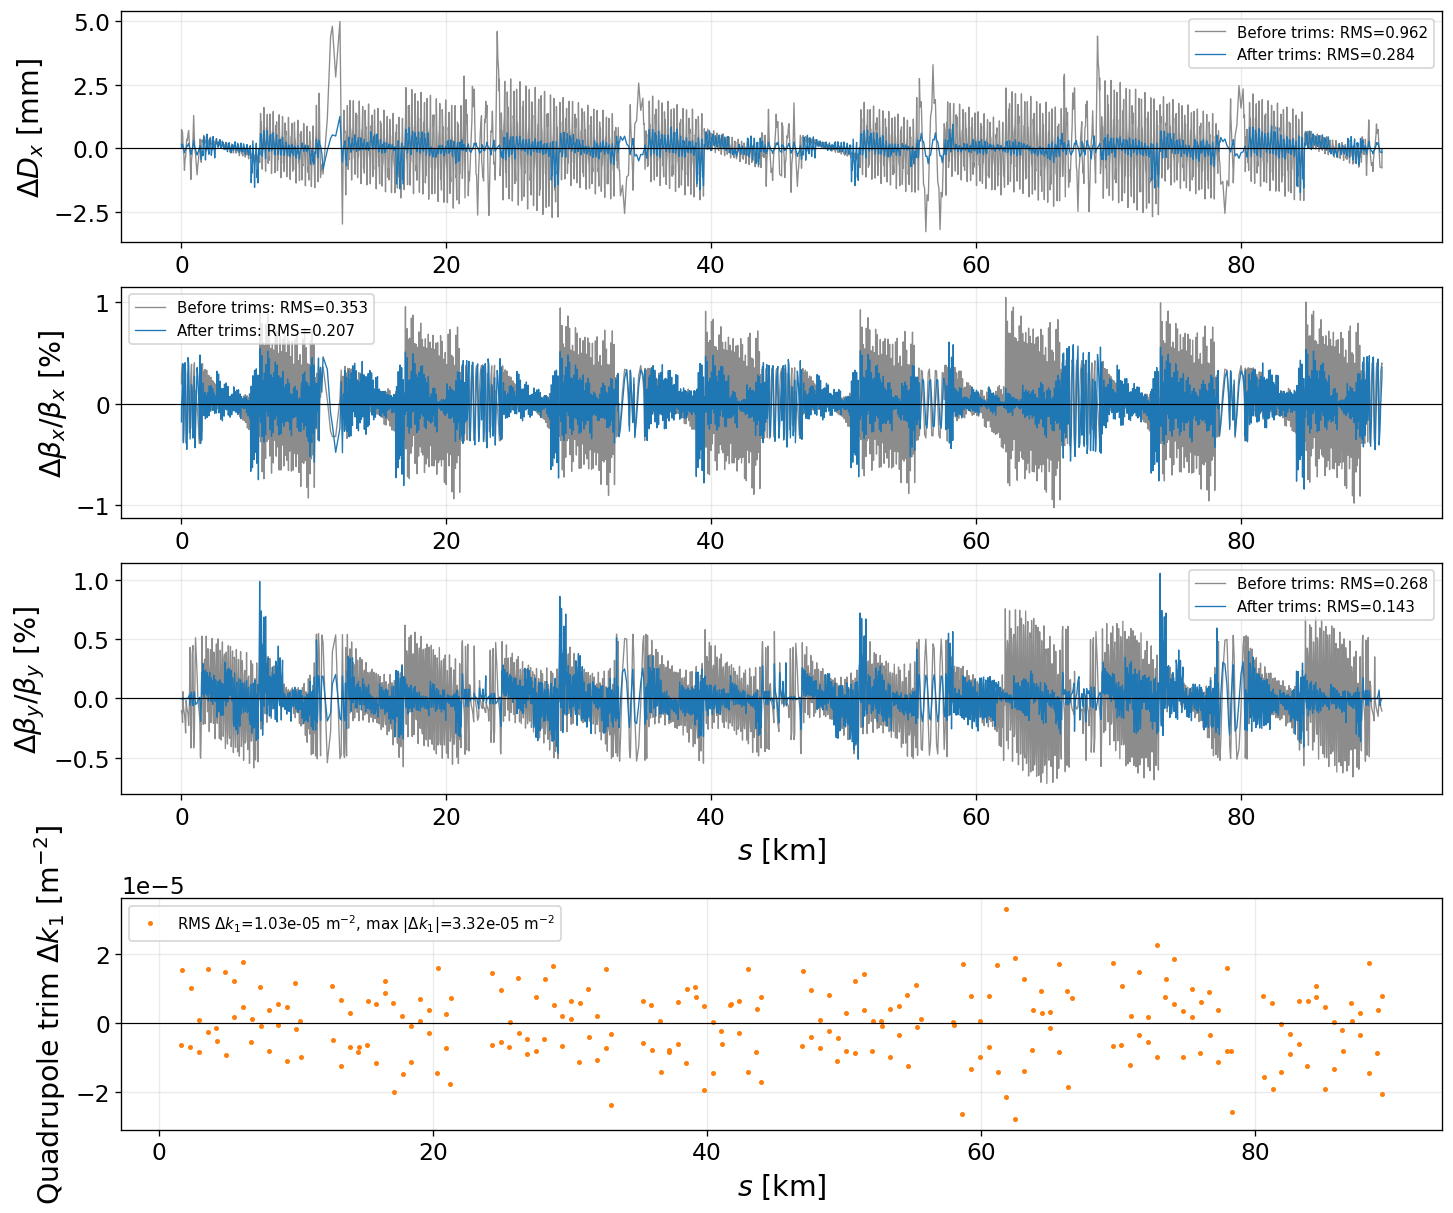

In [56]:
def quad_correction_metrics(twiss, reference, bpm_names, stage):
    names = list(np.asarray(bpm_names, dtype=str))
    case_index = twiss.rows.indices[names]
    reference_index = reference.rows.indices[names]
    dx_mm = 1e3 * (np.asarray(twiss.dx[case_index])
                     - np.asarray(reference.dx[reference_index]))
    betx_percent = 100 * (np.asarray(twiss.betx[case_index])
                           / np.asarray(reference.betx[reference_index]) - 1)
    bety_percent = 100 * (np.asarray(twiss.bety[case_index])
                           / np.asarray(reference.bety[reference_index]) - 1)
    local_rms = lambda values: float(np.sqrt(np.mean(np.asarray(values)**2)))
    return {
        "stage": stage,
        "Dx RMS [mm]": local_rms(dx_mm),
        "betx RMS [%]": local_rms(betx_percent),
        "bety RMS [%]": local_rms(bety_percent),
        "Qx error": float(twiss.qx - reference.qx),
        "Qy error": float(twiss.qy - reference.qy),
        "dQx error": float(twiss.dqx - reference.dqx),
        "dQy error": float(twiss.dqy - reference.dqy),
    }


quad_correction_summary = pd.DataFrame([
    quad_correction_metrics(twiss_before_quad_trims, twiss_ideal,
                            monitor_names, "Before quadrupole trims"),
    quad_correction_metrics(twiss_after_quad_trims, twiss_ideal,
                            monitor_names, "After quadrupole trims"),
])
display(quad_correction_summary)

names = list(np.asarray(monitor_names, dtype=str))
ib = twiss_before_quad_trims.rows.indices[names]
ia = twiss_after_quad_trims.rows.indices[names]
ir = twiss_ideal.rows.indices[names]
s_bpm_km = np.asarray(twiss_ideal.s[ir]) / 1e3

before = [
    1e3 * (np.asarray(twiss_before_quad_trims.dx[ib]) - np.asarray(twiss_ideal.dx[ir])),
    100 * (np.asarray(twiss_before_quad_trims.betx[ib]) / np.asarray(twiss_ideal.betx[ir]) - 1),
    100 * (np.asarray(twiss_before_quad_trims.bety[ib]) / np.asarray(twiss_ideal.bety[ir]) - 1),
]
after = [
    1e3 * (np.asarray(twiss_after_quad_trims.dx[ia]) - np.asarray(twiss_ideal.dx[ir])),
    100 * (np.asarray(twiss_after_quad_trims.betx[ia]) / np.asarray(twiss_ideal.betx[ir]) - 1),
    100 * (np.asarray(twiss_after_quad_trims.bety[ia]) / np.asarray(twiss_ideal.bety[ir]) - 1),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False, layout="constrained")
labels = [r"$\Delta D_x$ [mm]", r"$\Delta\beta_x/\beta_x$ [%]",
          r"$\Delta\beta_y/\beta_y$ [%]"]
for axis, values_before, values_after, ylabel in zip(axes[:3], before, after, labels):
    rms_before = np.sqrt(np.nanmean(np.asarray(values_before)**2))
    rms_after = np.sqrt(np.nanmean(np.asarray(values_after)**2))
    axis.plot(s_bpm_km, values_before, color="0.55", lw=0.8,
              label=f"Before trims: RMS={rms_before:.3g}")
    axis.plot(s_bpm_km, values_after, color="tab:blue", lw=0.8,
              label=f"After trims: RMS={rms_after:.3g}")
    axis.set_ylabel(ylabel)
    axis.legend(fontsize=9)

axes[2].set_xlabel(r"$s$ [km]")
trim_values = quad_trim_results["delta_k1"].to_numpy(float)
trim_rms = np.sqrt(np.nanmean(trim_values**2))
trim_max = np.nanmax(np.abs(trim_values))
axes[3].plot(quad_trim_results["s_km"], trim_values,
             ".", ms=4, color="tab:orange",
             label=(rf"RMS $\Delta k_1$={trim_rms:.3g} $\mathrm{{m}}^{{-2}}$, "
                    rf"max $|\Delta k_1|$={trim_max:.3g} $\mathrm{{m}}^{{-2}}$"))
axes[3].set_xlabel(r"$s$ [km]")
axes[3].set_ylabel(r"Quadrupole trim $\Delta k_1$ [$\mathrm{m}^{-2}$]")
axes[3].legend(fontsize=9)
for axis in axes:
    axis.axhline(0.0, color="black", lw=0.7)
    axis.grid(alpha=0.25)
    
plt.show()
